---
# Please don't change the text below, it's for formatting the documentation.
title: "Multimodal RAG with NVIDIA Nemotron and Hugging Face Tutorial"
description: "Learn how to build a multimodal RAG pipeline with NVIDIA Nemotron models and Hugging Face Transformers."
image: "https://huggingface.co/datasets/mrdbourke/learn-hf-images/resolve/main/learn-hf-multimodal-rag/multi-modal-rag-overview.png"
format: 
  html:
    code-fold: false
    page-layout: full
jupyter: python3
number-sections: true
toc: true
toc-depth: 3
toc-expand: 2 # expand toc to multiple levels
code-block-border-left: true
code-block-bg: true
---

<a target="_blank" href="https://colab.research.google.com/github/mrdbourke/learn-huggingface/blob/main/notebooks/hugging_face_multimodal_rag_tutorial.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

> **Note:** If you're running in Google Colab, make sure to enable GPU usage by going to Runtime -> Change runtime type -> select GPU.

[Book version](https://www.learnhuggingface.com/notebooks/hugging_face_multimodal_rag_tutorial) (easy to read) | [Source Code](hugging_face_multimodal_rag_tutorial.ipynb)

## Overview

We're going to build a multimodal RAG pipeline to retrieve food recipe images/texts given an input query of text or image.

Goals:

* Image input -> retrieved recipes
* Text input -> retrieved recipes
* Use the image + text embeddings because they are the best performing
    * Image only, text only embeddings perform well, however, according to the blog post, the image + text embeddings perform the best
* Optional: rerank the embeddings (this increases latency but improves results)
* Optional: generate an answer based on the output texts (this increases latency but improves results)

Ingredients:

* **Hardware used:** NVIDIA DGX Spark (though you could also use Google Colab for embedding creation)
* **Dataset used:** [https://huggingface.co/datasets/mrdbourke/recipe-synthetic-images-10k](https://huggingface.co/datasets/mrdbourke/recipe-synthetic-images-10k)
* **Embedding model used:** [https://huggingface.co/nvidia/llama-nemotron-embed-vl-1b-v2](https://huggingface.co/nvidia/llama-nemotron-embed-vl-1b-v2)
    * **Note:** By default we use the image + text embeddings as we have access to image and text pairs in our dataset, and according to the [launch blog post](https://huggingface.co/blog/nvidia/llama-nemotron-vl-1b), these work the best.
* **Rerank model used:** [https://huggingface.co/nvidia/llama-nemotron-rerank-vl-1b-v2](https://huggingface.co/nvidia/llama-nemotron-rerank-vl-1b-v2)
* **Generation model used:** [https://huggingface.co/Qwen/Qwen3-VL-2B-Instruct](https://huggingface.co/Qwen/Qwen3-VL-2B-Instruct) (note: you could use a larger model such as [Nemotron v3](https://huggingface.co/collections/nvidia/nvidia-nemotron-v3), however, this will require more compute resources)
* **Demo:** [https://huggingface.co/spaces/mrdbourke/multimodal-rag-with-nemotron](https://huggingface.co/spaces/mrdbourke/multimodal-rag-with-nemotron)

Steps: 

1. Build the demo application from embeddings -> retrieval -> rerank (optional) -> display results
2. Add in generation if this pipeline works well

## What we're going to build

We're going to build a multimodal RAG pipeline which will allow us to query a database of ~10,000 recipe images and texts with a text or an input image.

The pipeline will return the most relevant recipe images and texts with optional reranking and generative outputs.

![](https://huggingface.co/datasets/mrdbourke/learn-hf-images/resolve/main/learn-hf-multimodal-rag/multi-modal-rag-overview.png)

## Resources

All the code for this notebook was developed over a series of livestreams on YouTube.

This notebook is a succinct/cleaned up version of the trials and errors faced through the streams.

You can see them on my YouTube channel under the ["Multimodal RAG on the NVIDIA DGX Spark" playlist](https://studio.youtube.com/playlist/PL6vjgQ2-qJFe3cv0PkIQKgbpWR-aQlm4t/edit).

| Livestream (replay)| Date Streamed| Link | Brief overview |
| ----- | ----- | ----- | ----- |
| Part 1 – Creating a dataset | 19 Jan 2026  | [Watch replay](https://www.youtube.com/watch?v=KJY7meU0qFY) | We create a text/image recipe based dataset using real recipes from a Kaggle food.com dataset. We finished by uploading the dataset to Hugging Face for reuse later on. |
| Part 2 – Creating the pipeline | 20 Jan 2026 | [Watch replay](https://www.youtube.com/watch?v=X_yQ84v64ZA) | Builds the core multimodal RAG pipeline (how the pieces connect end-to-end after the dataset is ready).                                                |
| Part 3 – Putting it all together | 21 Jan 2026 | [Watch replay](https://www.youtube.com/watch?v=qap7gaJEjY4) | Integrates the components into a cohesive workflow and gets the full system running together.                                                          |
| Part 3.5 – Making a demo | 21 Jan 2026 | [Watch replay](https://www.youtube.com/watch?v=qj6c6Wkv_Z4) | Focuses on turning the pipeline into a usable demo (more “productizing” than core RAG mechanics).                                                      |
| Part 4 – Publishing our demo to Hugging Face | 22 Jan 2026 | [Watch replay](https://www.youtube.com/watch?v=XWmqcFiBvpU) | Publishes/deploys the demo (so others can try it—e.g., via Hugging Face tooling/hosting). |

## Definitions 

* **query** = A text/image based search term for what you're trying to find, for example, "recipes with tomatoes and parmesan" or an image of a kitchen bench of ingredients.
* **query embedding** = A numerical representation of your input query so it can be matched to document embeddings.
* **document embeddings** = A numerical representation of your database documents so they can be quickly matched to query embeddings.
    * For example, you have 10,000 images in a file and them embed them with an embedding model, save these embeddings to file, these would be called your document embeddings. Our goal is to find the most similar document embedding(s) for a given query embedding.

In [ ]:
# Set device (note: having CUDA is important otherwise everything will take far longer)
import torch

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"[INFO] Using device: {DEVICE}")

[INFO] Using device: cuda


## Load dataset

In [ ]:
from datasets import load_dataset

dataset = load_dataset(path="mrdbourke/recipe-synthetic-images-10k")
print(f"[INFO] Number of samples in our dataset: {len(dataset['train'])}")

[INFO] Number of samples in our dataset: 10096


In [ ]:
# View an example sample
print(dataset["train"][42]["recipe_markdown"])

# Artichoke Hearts Wrapped In Bacon

**ID:** 44272  
**Time:** 13 minutes  
**Number of Ratings:** 5

## Description

An appetizer from dr. and mrs. atkins. (quick & easy new diet cookbook)

## Ingredients

- bacon
- artichokes

## Steps (5 total)

1. Preheat the broiler
2. Cut the bacon slices in half , place on a baking sheet , and broil for 3 minutes
3. Let the bacon cool enough to handle
4. Wrap each artichoke half in a piece of bacon , broiled side facing inward , and secure with a toothpick
5. Broil 4 to 5 minutes , or until the bacon is brown and crisp

## Tags

`bacon`, `15-minutes-or-less`, `time-to-make`, `course`, `main-ingredient`, `cuisine`, `preparation`, `occasion`, `north-american`, `for-1-or-2`, `5-ingredients-or-less`, `appetizers`, `pork`, `american`, `oven`, `easy`, `beginner-cook`, `finger-food`, `holiday-event`, `romantic`, `broil`, `dietary`, `gluten-free`, `low-carb`, `valentines-day`, `free-of-something`, `low-in-something`, `meat`, `taste-mood`, `equipment`, `

In [4]:
import random
from pathlib import Path

# Get 100 random image paths
PATH_TO_IMAGES = "2026-01-19_03-52-56-recipe_to_pdf_and_image_outputs/images"

all_image_paths = list(Path(PATH_TO_IMAGES).rglob("*.png"))
print(f"[INFO] Number of total images: {len(all_image_paths)}")

image_paths_100 = random.sample(all_image_paths, k=100)

[INFO] Number of total images: 10096


In [5]:
# Get image paths in same order as dataset
# Get ids -> map to image path names 
all_image_ids = list(dataset["train"]["id"])
all_full_recipes = list(dataset["train"]["full_recipe"])

In [6]:
all_full_recipes_markdown = dataset["train"]["recipe_markdown"]
print(all_full_recipes_markdown[42])

# Artichoke Hearts Wrapped In Bacon

**ID:** 44272  
**Time:** 13 minutes  
**Number of Ratings:** 5

## Description

An appetizer from dr. and mrs. atkins. (quick & easy new diet cookbook)

## Ingredients

- bacon
- artichokes

## Steps (5 total)

1. Preheat the broiler
2. Cut the bacon slices in half , place on a baking sheet , and broil for 3 minutes
3. Let the bacon cool enough to handle
4. Wrap each artichoke half in a piece of bacon , broiled side facing inward , and secure with a toothpick
5. Broil 4 to 5 minutes , or until the bacon is brown and crisp

## Tags

`bacon`, `15-minutes-or-less`, `time-to-make`, `course`, `main-ingredient`, `cuisine`, `preparation`, `occasion`, `north-american`, `for-1-or-2`, `5-ingredients-or-less`, `appetizers`, `pork`, `american`, `oven`, `easy`, `beginner-cook`, `finger-food`, `holiday-event`, `romantic`, `broil`, `dietary`, `gluten-free`, `low-carb`, `valentines-day`, `free-of-something`, `low-in-something`, `meat`, `taste-mood`, `equipment`, `

## Load models

> **Note:** We are loading models from a custom commit version of `"nvidia/llama-nemotron-embed-vl-1b-v2"` and `"nvidia/llama-nemotron-rerank-vl-1b-v2"` so we can run them using `sdpa` attention rather than `flash_attention_2` (this is required for Hugging Face Spaces). If you have `flash_attention_2` installed locally, it is suggested you use the models with it for faster generation.

In [7]:
modality_to_tokens = {
    "image": 2048,
    "image_text": 10240,
    "text": 8192
}

In [8]:
%%time 

import torch
from transformers import (
    AutoModel,
    AutoModelForSequenceClassification,
    AutoProcessor,
)

# Model paths and commit hashes
# Note: The extra commit hashes are required to run the models without flash_attention_2
EMBED_MODEL_PATH = "nvidia/llama-nemotron-embed-vl-1b-v2"
EMBED_COMMIT_HASH = "5b5ca69c35bf6ec1484d2d5ff238626e67a745e2"

RERANK_MODEL_PATH = "nvidia/llama-nemotron-rerank-vl-1b-v2"
RERANK_COMMIT_HASH = "47e5a355d1a050c3e5f69d53f14964b1d34bcd9d"

# Load Embedding Model
embed_model = AutoModel.from_pretrained(
    EMBED_MODEL_PATH,
    revision=EMBED_COMMIT_HASH,
    dtype=torch.bfloat16,
    trust_remote_code=True,
    attn_implementation="sdpa",
    device_map="auto",
).eval()

# Set embed processor kwargs
# Note: These are the suggest settings from the embed model card
embed_modality = "image_text"
embed_processor_kwargs = {
    "max_input_tiles": 6,
    "use_thumbnail": True,
    "p_max_length": modality_to_tokens[embed_modality]
}

# Load embedding model processer
embed_processor = AutoProcessor.from_pretrained(
    EMBED_MODEL_PATH,
    revision=EMBED_COMMIT_HASH,
    trust_remote_code=True,
    **embed_processor_kwargs
)

print(f"[INFO] Loaded embedding model from commit: {EMBED_COMMIT_HASH[:7]}")
print(f"[INFO] Embed processor using p_max_length: {embed_processor.p_max_length}")

# Load Rerank Model
rerank_model = AutoModelForSequenceClassification.from_pretrained(
    RERANK_MODEL_PATH,
    revision=RERANK_COMMIT_HASH,
    dtype=torch.bfloat16,
    trust_remote_code=True,
    attn_implementation="sdpa",
    device_map="auto",
).eval()

# Set rerank processor kwargs
# Note: These are the suggest settings from the rerank model card
rerank_modality = "image_text"
rereank_processor_kwargs = {
    "max_input_tiles": 6,
    "use_thumbnail": True,
    "rerank_max_length": modality_to_tokens[rerank_modality]
}

rerank_processor = AutoProcessor.from_pretrained(
    RERANK_MODEL_PATH,
    revision=RERANK_COMMIT_HASH,
    trust_remote_code=True,
)

print(f"[INFO] Loaded rerank model from commit: {RERANK_COMMIT_HASH[:7]}")
print(f"[INFO] Rerank processor using rerank_max_length: {rerank_processor.rerank_max_length}")

/home/mrdbourke/miniforge3/envs/ai/lib/python3.12/site-packages/torch/cuda/__init__.py:283: UserWarning: 
    Found GPU0 NVIDIA GB10 which is of cuda capability 12.1.
    Minimum and Maximum cuda capability supported by this version of PyTorch is
    (8.0) - (12.0)
    
  warnings.warn(


[INFO] Loaded embedding model from commit: 5b5ca69
[INFO] Embed processor using p_max_length: 10240
[INFO] Loaded rerank model from commit: 47e5a35
[INFO] Rerank processor using rerank_max_length: 10240


## Create/Load embeddings

We could create/load the image or text embeddings only.

But we're going to use the image + text embeddings (combined embedding of image & text) as these are reported to perform the best.

These embeddings were created by passing the image of the recipe (`dataset["train"]["image"]`) + the markdown text of the recipe (`dataset["train"]["recipe_markdown"]`)to the embedding model.

See: [https://huggingface.co/blog/nvidia/llama-nemotron-vl-1b](https://huggingface.co/blog/nvidia/llama-nemotron-vl-1b)

> **Note:** All of these embeddings were created with [`llama-nemotron-embed-vl-1b-v2`](https://huggingface.co/nvidia/llama-nemotron-embed-vl-1b-v2). Therefore to interact with them using queries, we must embed the query with the same model.
>
> Embedding creation is often a one-time practice, as in, you create document embeddings once and store them in a file/database and then import them when you'd like to use them. The only time you would need to update your document embeddings would be if you decided to update the embedding model you used.

In [ ]:
import os
from tqdm.auto import tqdm
from safetensors.torch import save_file, load_file

PATH_TO_EMBEDDING_FILE = "image_text_embeddings_10k.safetensors"
CREATE_EMBEDDINGS = False
IMAGE_TEXT_BATCH_SIZE = 8 # adjust depending on the size of your GPU, create image/text embeddings in batches to prevent out of memory issues

image_text_embeddings = None

# Check if the file exists
if os.path.exists(PATH_TO_EMBEDDING_FILE):
    print(f"[INFO] File found! Loading embeddings from {PATH_TO_EMBEDDING_FILE}...")
    image_text_embeddings = load_file(PATH_TO_EMBEDDING_FILE)
    image_text_embeddings = image_text_embeddings["image_text_embeddings"].to(DEVICE)
    print(f"[INFO] Embeddings shape: {image_text_embeddings.shape} | Device: {image_text_embeddings.device}")
else:
    print(f"[INFO] Embedding file at {PATH_TO_EMBEDDING_FILE} not found, setting CREATE_EMBEDDINGS=True")
    CREATE_EMBEDDINGS = True

# If need to create embeddings, do so
if CREATE_EMBEDDINGS:
    print("[INFO] Proceeding to create new embeddings...")

    embedding_modality = "image_text"
    max_token_length = modality_to_tokens[embedding_modality]
    embed_model.processor.p_max_length = max_token_length

    print(f"[INFO] Creating image+text embeddings with p_max_length: {embed_model.processor.p_max_length}")
    print(f"[INFO] Creating image+text embeddings with batch_size: {IMAGE_TEXT_BATCH_SIZE}")

    image_text_embedding_chunks = []
    for i in tqdm(range(0, len(dataset["train"]), IMAGE_TEXT_BATCH_SIZE), desc="Embedding images + texts"):
        # Create a range of indices to select
        indicies_to_select = list(range(i, i+8))

        # Make sure indices stay lower than the total number of samples
        indicies_to_select = [item for item in indicies_to_select if item <= len(dataset["train"]) - 1]
        
        # Select the portion of the dataset with the target indices
        dataset_chunk = dataset["train"].select(indices=indicies_to_select)
        images_to_embed = dataset_chunk["image"]
        texts_to_embed = dataset_chunk["recipe_markdown"]

        # print(f"[INFO] On indicies: {indicies_to_select}")

        # Perform the embedding on image + text chunks
        with torch.inference_mode():
            image_text_embed_chunk = embed_model.encode_documents(images=images_to_embed, 
                                                                texts=texts_to_embed)
        image_text_embedding_chunks.append(image_text_embed_chunk)

    image_text_embeddings_all = torch.cat(image_text_embedding_chunks, dim=0)
    print(f"[INFO] Finished creating image + text combined embeddings!\nFinal shape: {image_text_embeddings_all.shape}")
    print(f"[INFO] Saving embeddings to: {PATH_TO_EMBEDDING_FILE}")
    save_file({"image_text_embeddings": image_text_embeddings_all}, PATH_TO_EMBEDDING_FILE)

[INFO] File found! Loading embeddings from image_text_embeddings_10k.safetensors...
[INFO] Embeddings shape: torch.Size([10096, 2048]) | Device: cuda:0


In [10]:
# Show an example embedding
example_embeddings = image_text_embeddings[0]
print(f"[INFO] Example embeddings shape: {example_embeddings.shape}")
print(f"[INFO] Example embeddings first 10 vales:")
example_embeddings[:10]

[INFO] Example embeddings shape: torch.Size([2048])
[INFO] Example embeddings first 10 vales:


tensor([ 0.5430,  1.3203,  2.7969,  2.2188,  3.3125, -0.5352,  0.3750, -0.2021,
         0.5000,  2.1406], device='cuda:0', dtype=torch.bfloat16)

We have 10,096 embeddings, one for each of our recipe image + text combos. They are of size `2048` which means they are represented by 2048 numerical values each. 

## Retrieve samples based on input query

Because our embeddings store image + text representations in one, we can search via input text or via input image (or if we really wanted to, we can search via both).

To keep things simple, we'll start with querying our embeddings using text.

> **Note:** For this tutorial we are searching our embeddings using either text *or* images. A noteable extension would be to make our pipeline work with a *combined* text and image input.
>
> For more on this, I refer the reader to the [`llama-nemotron-embed-vl-1b-v2`](https://huggingface.co/nvidia/llama-nemotron-embed-vl-1b-v2) documentation.

An input query can be any kind of text.

For example, it could be specific such as `"recipes with tomato and parmesan cheese"` or vague such as `"summer lunch ideas"`.

You could even input non-food related text such as `"best office furniture deals"` and the model will still return results, however, they will likely not be very related to the query as our system is specifically designed with food recipes in mind.

In [11]:
%%time

from PIL import Image

query = "recipes with tomato and parmesan cheese"

# Note: our query could also be a PIL input image
# from PIL import Image
# query = Image.open(path_to_image)

# Create helper function for l2_normalization
# Note: for non-normalized embeddings use dot product for similarity, for l2 normalization, use cosine similarity
def _l2_normalize(x: torch.Tensor, 
                  eps: float = 1e-12) -> torch.Tensor:
    return x / (x.norm(p=2, dim=-1, keepdim=True) + eps)

def match_query_to_embeddings(query: str | Image.Image,
                              target_embeddings_to_match: torch.Tensor,
                              top_k: int = 100) -> tuple[torch.Tensor, torch.Tensor]:
    
    """Matches query of input string or image to target input embeddings.
    
    Returns tuple of (scores, sorted_indices)."""
    with torch.inference_mode():
        if isinstance(query, Image.Image):
            # Embed the query (image)
            query_embeddings = embed_model.encode_documents(images=[query])
        else:
            # Embed the query (str)
            query_embeddings = embed_model.encode_queries([query])
    
    # Compute cosine similarity (use cosine for normalized tensors)
    cos_sim = _l2_normalize(query_embeddings) @ _l2_normalize(target_embeddings_to_match).T

    # Flatten logits the 1D array (handle both [batch_size] and [batch_size, 1] shapes)
    cos_sim_flat = cos_sim.flatten()

    # Sort the indices
    sorted_indices = torch.argsort(cos_sim_flat, descending=True)[:top_k]

    # Get the top scores (sort by the top indicies)
    sorted_scores = cos_sim_flat[sorted_indices][:top_k]

    return sorted_scores, sorted_indices

# Match the input query to the target embeddings and get back scores and indices
result_sorted_scores, result_sorted_indices = match_query_to_embeddings(query=query,
                                                                        target_embeddings_to_match=image_text_embeddings,
                                                                        top_k=100) # get back the top 100 samples

CPU times: user 294 ms, sys: 196 ms, total: 490 ms
Wall time: 490 ms


In [12]:
result_sorted_scores, result_sorted_indices

(tensor([0.5000, 0.4922, 0.4863, 0.4805, 0.4785, 0.4688, 0.4668, 0.4668, 0.4590,
         0.4590, 0.4551, 0.4531, 0.4531, 0.4473, 0.4473, 0.4453, 0.4453, 0.4434,
         0.4434, 0.4434, 0.4414, 0.4395, 0.4395, 0.4395, 0.4355, 0.4355, 0.4355,
         0.4336, 0.4336, 0.4336, 0.4336, 0.4316, 0.4316, 0.4316, 0.4316, 0.4316,
         0.4316, 0.4277, 0.4277, 0.4277, 0.4277, 0.4277, 0.4277, 0.4277, 0.4258,
         0.4258, 0.4258, 0.4258, 0.4258, 0.4258, 0.4258, 0.4258, 0.4258, 0.4238,
         0.4238, 0.4238, 0.4238, 0.4238, 0.4238, 0.4238, 0.4238, 0.4219, 0.4219,
         0.4219, 0.4219, 0.4219, 0.4219, 0.4219, 0.4199, 0.4199, 0.4199, 0.4199,
         0.4199, 0.4199, 0.4199, 0.4199, 0.4199, 0.4180, 0.4180, 0.4180, 0.4180,
         0.4180, 0.4180, 0.4160, 0.4160, 0.4160, 0.4160, 0.4160, 0.4160, 0.4141,
         0.4141, 0.4141, 0.4141, 0.4141, 0.4141, 0.4121, 0.4121, 0.4121, 0.4121,
         0.4121], device='cuda:0', dtype=torch.bfloat16),
 tensor([6936, 3471, 5164, 5805, 4481, 7263, 2076, 

In [13]:
result_sorted_scores.shape, result_sorted_indices.shape

(torch.Size([100]), torch.Size([100]))

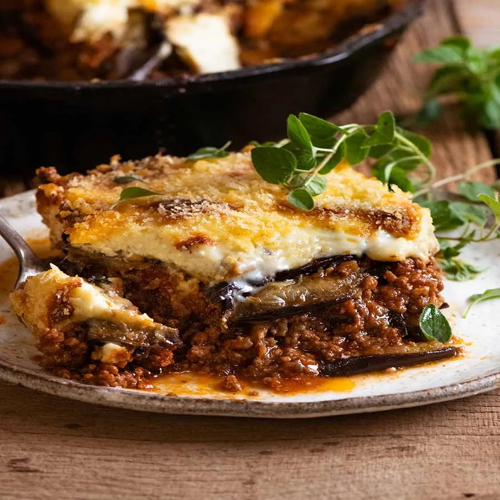

In [14]:
# Test with an image
# test_image_path = "banana_bread.png"
test_image_path = "moussaka.jpeg"
test_image_query = Image.open(test_image_path)
test_image_query.resize(size=(500, 500))

In [15]:
image_result_sorted_scores, image_result_sorted_indices = match_query_to_embeddings(query=test_image_query,
                                                                                    target_embeddings_to_match=image_text_embeddings,
                                                                                    top_k=100) # get back the top 100 samples

In [16]:
image_result_sorted_scores, image_result_sorted_indices

(tensor([0.3613, 0.3574, 0.3535, 0.3438, 0.3418, 0.3398, 0.3398, 0.3379, 0.3379,
         0.3379, 0.3359, 0.3359, 0.3320, 0.3320, 0.3301, 0.3301, 0.3301, 0.3301,
         0.3301, 0.3281, 0.3281, 0.3281, 0.3281, 0.3281, 0.3262, 0.3262, 0.3262,
         0.3262, 0.3262, 0.3262, 0.3262, 0.3262, 0.3242, 0.3242, 0.3242, 0.3242,
         0.3242, 0.3242, 0.3242, 0.3242, 0.3242, 0.3223, 0.3223, 0.3223, 0.3203,
         0.3203, 0.3203, 0.3203, 0.3203, 0.3203, 0.3203, 0.3203, 0.3203, 0.3203,
         0.3203, 0.3184, 0.3184, 0.3184, 0.3184, 0.3164, 0.3164, 0.3164, 0.3164,
         0.3164, 0.3164, 0.3145, 0.3145, 0.3145, 0.3145, 0.3145, 0.3145, 0.3145,
         0.3125, 0.3125, 0.3125, 0.3125, 0.3125, 0.3125, 0.3125, 0.3125, 0.3125,
         0.3125, 0.3105, 0.3105, 0.3105, 0.3105, 0.3105, 0.3105, 0.3105, 0.3105,
         0.3105, 0.3105, 0.3105, 0.3105, 0.3105, 0.3105, 0.3105, 0.3105, 0.3086,
         0.3086], device='cuda:0', dtype=torch.bfloat16),
 tensor([ 7069,  9628,  5289,  9757,  9651,  3742, 

In [17]:
print(dataset["train"][image_result_sorted_indices[0].item()]["recipe_markdown"])

# Mediterranean Eggplant  Aubergine  Cakes

**ID:** 112586  
**Time:** 50 minutes  
**Number of Ratings:** 6

## Description

A lovely vegetarian appetizer. i always sweat my eggplants before making this, to remove the bitter juices. i find it has a better flavor that way.

## Ingredients

- eggplant
- olive oil
- garlic cloves
- egg white
- fresh breadcrumb
- flour
- parmesan cheese
- feta cheese
- fresh parsley
- fresh basil
- green onions
- salt
- fresh ground black pepper

## Steps (11 total)

1. Preheat oven to 375f
2. Brush eggplant slices evenly with olive oil
3. Bake for 20 minutes until golden brown and tender
4. Remove from oven , and finely dice the eggplant slices
5. In a medium bowl , combine the chopped eggplant pieces with the garlic , egg whites , parmesan , feta , breadcrumbs , basil and parsley and green onions
6. Add the salt and pepper in quantities at your discretion
7. Mix everything well and place in the refrigerator 20min to firm up
8. Divide the mixture into 6-

Let's test another text-based query.

In [19]:
test_query_text = "Banana Sour Cream Bread"
text_result_sorted_scores, text_result_sorted_indices = match_query_to_embeddings(query=test_query_text,
                                                                                  target_embeddings_to_match=image_text_embeddings,
                                                                                  top_k=100) # get back the top 100 samples
print(dataset["train"][text_result_sorted_indices[0].item()]["recipe_markdown"])

# Banana Sour Cream Bread  Oamc

**ID:** 309946  
**Time:** 70 minutes  
**Number of Ratings:** 7

## Description

This is the best banana bread ever.  the sour cream really gives it something extra.  once you use this recipe you will throw out all your other banana bread recipes.

## Ingredients

- white sugar
- ground cinnamon
- butter
- eggs
- bananas
- sour cream
- vanilla extract
- salt
- baking soda
- all-purpose flour
- walnuts

## Steps (11 total)

1. Preheat oven to 300 degrees f
2. Grease four 7x3 inch loaf pans
3. In a small bowl , stir together 1 / 4 cup white sugar and 1 teaspoon cinnamon
4. Dust pans lightly with cinnamon and sugar mixture
5. In a large bowl , cream butter and 3 cups sugar
6. Mix in eggs , mashed bananas , sour cream , vanilla and cinnamon
7. Mix in salt , baking soda and flour
8. Stir in nuts
9. Divide into prepared pans
10. Bake for 1 hour , until a toothpick inserted in center comes out clean
11. I know four loaves is a lot , but remember you can freez

## Displaying top results

Let's write some nice visualization code to view the top results.

In [20]:
def get_top_n_scores_and_samples(scores, indicies, top_n=3):
    if top_n > len(scores):
        top_n == len(scores)

    top_samples = dataset["train"].select(indicies[:3])
    top_scores_and_samples = [] 
    for score, sample in zip(scores, top_samples):
        top_scores_and_samples.append({"score": round(score.item(), 4),
                                       "sample": sample})
    return top_scores_and_samples

In [21]:
top_3_scores_and_samples = get_top_n_scores_and_samples(scores=image_result_sorted_scores,
                                                        indicies=image_result_sorted_indices)
print(f"[INFO] Got num top scores and samples: {top_3_scores_and_samples}")

[INFO] Got num top scores and samples: [{'score': 0.3613, 'sample': {'name': 'mediterranean eggplant  aubergine  cakes', 'id': 112586, 'minutes': 50, 'contributor_id': 125458, 'submitted': datetime.datetime(2005, 3, 3, 0, 0), 'tags': "['60-minutes-or-less', 'time-to-make', 'course', 'main-ingredient', 'cuisine', 'preparation', 'occasion', 'appetizers', 'main-dish', 'vegetables', 'greek', 'easy', 'european', 'dinner-party', 'finger-food', 'vegetarian', 'italian', 'dietary', 'high-calcium', 'inexpensive', 'high-in-something', 'presentation']", 'nutrition': '[569.8, 61.0, 24.0, 41.0, 43.0, 65.0, 10.0]', 'n_steps': 11, 'steps': "['preheat oven to 375f', 'brush eggplant slices evenly with olive oil', 'bake for 20 minutes until golden brown and tender', 'remove from oven , and finely dice the eggplant slices', 'in a medium bowl , combine the chopped eggplant pieces with the garlic , egg whites , parmesan , feta , breadcrumbs , basil and parsley and green onions', 'add the salt and pepper in 

In [ ]:
import io, ast, base64
from IPython.display import HTML

# Note: Got Claude to help generate a display function for our results (to make them look pretty)
def display_query_results(input_query, results, modality_match="image + text"):
    """
    Display query results in a Jupyter notebook with text and image matches.
    
    Args:
        input_query: Either a string or PIL.Image.Image
        results: List of dicts with 'score' and 'sample' keys
        modality_match: String describing the matching modality
    """
    assert len(results) <= 3, f"Expected at most 3 results, got {len(results)}"
    
    # --- Display Query Section ---
    display(HTML(f"""
    <div style='margin-bottom: 20px;'>
        <h2 style='margin: 0 0 8px 0; font-family: system-ui, sans-serif;'>Query</h2>
        <p style='color: #666; margin: 0; font-size: 13px;'>Modality: {modality_match}</p>
    </div>
    """))
    
    if isinstance(input_query, str):
        display(HTML(f"<p style='font-size: 16px; margin: 10px 0 20px 0;'>{input_query}</p>"))
    elif isinstance(input_query, Image.Image):
        display(input_query.resize(size=(300, 300)))
    else:
        display(HTML(f"<p>Unknown query type: {type(input_query)}</p>"))
    
    display(HTML("<hr style='border: none; border-top: 1px solid #ddd; margin: 20px 0;'>"))
    
    # --- Text Matches Section (Single Row) ---
    display(HTML("<h2 style='font-family: system-ui, sans-serif; margin-bottom: 15px;'>Text Matches</h2>"))
    
    cards_html = "<div style='display: flex; gap: 16px; width: 100%;'>"
    
    for i, result in enumerate(results):
        score = result['score']
        sample = result['sample']
        
        recipe_name = sample.get('name', 'Unknown Recipe').title()
        recipe_id = sample.get('id', 'N/A')
        minutes = sample.get('minutes', 'N/A')
        num_ratings = sample.get('number_of_ratings', 0)
        description = sample.get('description', 'No description available.')
        
        # Parse ingredients
        ingredients_raw = sample.get('ingredients', '[]')
        if isinstance(ingredients_raw, str):
            try:
                ingredients = ast.literal_eval(ingredients_raw)
            except:
                ingredients = []
        else:
            ingredients = ingredients_raw
        
        # Parse steps
        steps_raw = sample.get('steps', '[]')
        if isinstance(steps_raw, str):
            try:
                steps = ast.literal_eval(steps_raw)
            except:
                steps = []
        else:
            steps = steps_raw
        
        # Get 1 review
        reviews = sample.get('random_reviews', [])
        single_review = reviews[0] if reviews else None
        
        # Build ingredients list
        ingredients_list = ', '.join(ingredients[:8])
        if len(ingredients) > 8:
            ingredients_list += f' (+{len(ingredients) - 8} more)'
        
        # Build steps list
        steps_html = ''.join([
            f"<div style='margin: 4px 0; font-size: 12px;'><strong>{j+1}.</strong> {step.capitalize()[:80]}{'...' if len(step) > 80 else ''}</div>"
            for j, step in enumerate(steps[:5])
        ])
        if len(steps) > 5:
            steps_html += f"<div style='font-size: 11px; color: #666;'>...and {len(steps) - 5} more steps</div>"
        
        # Build review section
        review_html = ""
        if single_review:
            review_html = f"""
            <div style='border-top: 1px solid #eee; padding-top: 10px; margin-top: 10px;'>
                <div style='font-weight: bold; font-size: 12px; margin-bottom: 4px;'>Review</div>
                <div style='font-size: 11px; color: #444; font-style: italic;'>"{single_review[:150]}{'...' if len(single_review) > 150 else ''}"</div>
            </div>
            """
        
        # Build the card
        cards_html += f"""
        <div style='flex: 1; border: 1px solid #ddd; padding: 16px; background: #fff; font-family: system-ui, sans-serif; font-size: 13px; min-width: 0; max-height: 450px; overflow-y: auto;'>
            <div style='display: flex; justify-content: space-between; align-items: start; margin-bottom: 10px;'>
                <div style='font-weight: bold; font-size: 14px;'>{recipe_name}</div>
                <div style='font-size: 11px; color: #666;'>#{i+1} | {score:.4f}</div>
            </div>
            
            <div style='font-size: 11px; color: #666; margin-bottom: 10px;'>
                {minutes} min · {num_ratings} ratings · ID: {recipe_id}
            </div>
            
            <div style='margin-bottom: 12px; font-style: italic; color: #444; font-size: 12px;'>
                {description[:120]}{'...' if len(description) > 120 else ''}
            </div>
            
            <div style='margin-bottom: 12px;'>
                <div style='font-weight: bold; font-size: 12px; margin-bottom: 4px;'>Ingredients</div>
                <div style='font-size: 12px; color: #333;'>{ingredients_list}</div>
            </div>
            
            <div style='margin-bottom: 10px;'>
                <div style='font-weight: bold; font-size: 12px; margin-bottom: 4px;'>Steps</div>
                {steps_html}
            </div>
            
            {review_html}
        </div>
        """
    
    cards_html += "</div>"
    display(HTML(cards_html))
    
    display(HTML("<hr style='border: none; border-top: 1px solid #ddd; margin: 20px 0;'>"))
    
    # --- Image Matches Section (Single Row) ---
    display(HTML("<h2 style='font-family: system-ui, sans-serif; margin-bottom: 15px;'>Image Matches</h2>"))
    
    images_html = "<div style='display: flex; gap: 16px;'>"
    
    for i, result in enumerate(results):
        score = result['score']
        sample = result['sample']
        recipe_name = sample.get('name', 'Unknown Recipe').title()
        img = sample.get('image')
        
        if img is not None and isinstance(img, Image.Image):
            buffered = io.BytesIO()
            img_copy = img.copy()
            img_copy.thumbnail((350, 350))
            img_copy.save(buffered, format="PNG")
            img_base64 = base64.b64encode(buffered.getvalue()).decode()
            
            images_html += f"""
            <div style='flex: 1; text-align: center; border: 1px solid #ddd; padding: 12px; background: #fff; font-family: system-ui, sans-serif;'>
                <img src='data:image/png;base64,{img_base64}' style='max-width: 100%; border-radius: 4px;'/>
                <div style='margin-top: 8px; font-size: 12px; color: #666;'>#{i+1} · {score:.4f}</div>
                <div style='font-size: 13px; font-weight: 500; margin-top: 4px;'>{recipe_name}</div>
            </div>
            """
        else:
            images_html += f"""
            <div style='flex: 1; text-align: center; border: 1px solid #ddd; padding: 12px; background: #fafafa; height: 200px; display: flex; flex-direction: column; align-items: center; justify-content: center; font-family: system-ui, sans-serif;'>
                <div style='color: #666; font-size: 13px;'>No image available</div>
                <div style='font-size: 13px; margin-top: 8px;'>#{i+1} · {recipe_name}</div>
            </div>
            """
    
    images_html += "</div>"
    display(HTML(images_html))
    
    display(HTML(f"<p style='color: #666; margin-top: 16px; font-size: 12px; font-family: system-ui, sans-serif;'>Displayed {len(results)} results</p>"))

display_query_results(
    input_query=test_image_query,
    results=top_3_scores_and_samples,
    modality_match="image + text"
)

## Rerank the outputs

We get back some good results to start, however, these results could potentially be improved via reranking.

To do so, we can use [`nvidia/llama-nemotron-rerank-vl-1b-v2`](https://huggingface.co/nvidia/llama-nemotron-rerank-vl-1b-v2).

In [32]:
# Need image + text pairs for reranking
test_query_text = "Banana Sour Cream Bread"
text_result_sorted_scores, text_result_sorted_indices

(tensor([0.5898, 0.5547, 0.5430, 0.5195, 0.5156, 0.5117, 0.5000, 0.4961, 0.4961,
         0.4922, 0.4902, 0.4883, 0.4805, 0.4727, 0.4707, 0.4688, 0.4629, 0.4609,
         0.4609, 0.4531, 0.4531, 0.4512, 0.4453, 0.4434, 0.4434, 0.4414, 0.4395,
         0.4395, 0.4375, 0.4375, 0.4316, 0.4316, 0.4316, 0.4277, 0.4238, 0.4219,
         0.4219, 0.4180, 0.4160, 0.4160, 0.4160, 0.4141, 0.4141, 0.4141, 0.4121,
         0.4062, 0.4023, 0.4023, 0.4023, 0.4004, 0.4004, 0.3984, 0.3984, 0.3984,
         0.3984, 0.3984, 0.3965, 0.3965, 0.3965, 0.3965, 0.3965, 0.3945, 0.3926,
         0.3926, 0.3926, 0.3906, 0.3906, 0.3906, 0.3906, 0.3906, 0.3887, 0.3887,
         0.3887, 0.3887, 0.3887, 0.3887, 0.3867, 0.3848, 0.3848, 0.3848, 0.3848,
         0.3848, 0.3828, 0.3828, 0.3809, 0.3809, 0.3809, 0.3789, 0.3789, 0.3789,
         0.3789, 0.3789, 0.3789, 0.3789, 0.3789, 0.3770, 0.3770, 0.3770, 0.3770,
         0.3770], device='cuda:0', dtype=torch.bfloat16),
 tensor([5929, 5988, 5880, 9484, 9101, 5166, 4633, 

In [34]:
%%time
import time

rerank_start_time = time.time()

NUM_TOP_SAMPLES_TO_RERANK = 20 # Note: the more samples you try to rerank, the longer it will take (reranking is a one-to-one comparison)

# Select top samples to rerank from dataset
dataset_samples_to_rerank = dataset["train"].select(text_result_sorted_indices[:NUM_TOP_SAMPLES_TO_RERANK])
print(f"[INFO] Reranking number of top samples: {len(dataset_samples_to_rerank)}")
texts_to_rerank = dataset_samples_to_rerank["recipe_markdown"]
images_to_rerank = dataset_samples_to_rerank["image"]

# Format our top samples for reranking
samples_to_rerank = [{
    "question": test_query_text,
    "doc_text": text,
    "doc_image": image} for text, image in zip(texts_to_rerank, images_to_rerank)]

# Process the input samples
batch_dict_rerank = rerank_processor.process_queries_documents_crossencoder(samples_to_rerank)

# Move samples to target device
batch_dict_rerank = {
    k: v.to(DEVICE) if isinstance(v, torch.Tensor) else v for k, v in batch_dict_rerank.items()
}

# Run rerank inference
with torch.inference_mode():
    rerank_outputs = rerank_model(**batch_dict_rerank, return_dict=True)

rerank_end_time = time.time()
rerank_total_time = rerank_end_time - rerank_start_time
print(f"[INFO] Total rerank time for {len(dataset_samples_to_rerank)} samples: {rerank_total_time:.2f} seconds") 

[INFO] Reranking number of top samples: 20
[INFO] Total rerank time for 20 samples: 16.66 seconds
CPU times: user 4.47 s, sys: 2.17 s, total: 6.64 s
Wall time: 16.7 s


> **Note:** Depending on your pipeline, reranking may or may not be worth it. If you are reranking image + text, keep in mind, this will likely take a significant portion of your overal retrieval time.

In [35]:
# Get logits
rerank_logits = rerank_outputs.logits
rerank_logits_flat = rerank_logits.squeeze(-1)

# Get sorted indices
rerank_sorted_indicies = torch.argsort(rerank_logits_flat, descending=True)
rerank_sorted_indicies

tensor([ 0,  1,  7,  6,  8,  2,  3, 11, 13, 18,  5, 14, 17,  4,  9, 19, 15, 10,
        12, 16], device='cuda:0')

### Create a helper function for reranking input samples 

See here for steps on how to do this: [https://huggingface.co/nvidia/llama-nemotron-rerank-vl-1b-v2](https://huggingface.co/nvidia/llama-nemotron-rerank-vl-1b-v2)

In [36]:
def rerank_samples(
    dataset,
    query_text: str,
    sorted_indices: list | torch.Tensor,
    num_samples_to_rerank: int,
    rerank_model,
    rerank_processor,
    device: str = "cuda",
    text_column: str = "recipe_markdown",
    image_column: str = "image",
    dataset_split: str = "train",
) -> torch.Tensor:
    """
    Rerank top samples from a dataset using a vision-language reranker model.

    Args:
        dataset: HuggingFace dataset containing text and images.
        query_text: The query string to rerank against.
        sorted_indices: Pre-sorted indices from initial retrieval (e.g., from embedding search).
        num_samples_to_rerank: Number of top samples to rerank.
        rerank_model: Loaded reranker model (e.g., llama-nemotron-rerank-vl-1b-v2).
        rerank_processor: Processor for the reranker model.
        device: Device to run inference on ("cuda" or "cpu").
        text_column: Name of the text column in the dataset.
        image_column: Name of the image column in the dataset.
        dataset_split: Dataset split to use (e.g., "train", "test").

    Returns:
        torch.Tensor: Reranked indices mapped back to original dataset indices.
    """
    # Select top samples to rerank from dataset
    top_indices = sorted_indices[:num_samples_to_rerank]
    dataset_samples_to_rerank = dataset[dataset_split].select(top_indices)

    texts_to_rerank = dataset_samples_to_rerank[text_column]
    images_to_rerank = dataset_samples_to_rerank[image_column]

    # Format samples for reranking
    samples_to_rerank = [
        {
            "question": query_text,
            "doc_text": text,
            "doc_image": image,
        }
        for text, image in zip(texts_to_rerank, images_to_rerank)
    ]

    # Process the input samples
    batch_dict_rerank = rerank_processor.process_queries_documents_crossencoder(
        samples_to_rerank
    )

    # Move samples to target device
    batch_dict_rerank = {
        k: v.to(device) if isinstance(v, torch.Tensor) else v
        for k, v in batch_dict_rerank.items()
    }

    # Run rerank inference
    with torch.inference_mode():
        rerank_outputs = rerank_model(**batch_dict_rerank, return_dict=True)

    # Get logits and sort
    rerank_logits = rerank_outputs.logits.squeeze(-1)
    rerank_sorted_indices = torch.argsort(rerank_logits, descending=True)

    return dataset_samples_to_rerank, rerank_sorted_indices

dataset_samples_to_rerank, rerank_sorted_indicies_function = rerank_samples(sorted_indices=text_result_sorted_indices,
                                                                            dataset=dataset,
                                                                            dataset_split="train",
                                                                            query_text=test_query_text,
                                                                            num_samples_to_rerank=20, 
                                                                            rerank_model=rerank_model, 
                                                                            rerank_processor=rerank_processor)

In [38]:
def display_rerank_changes(rerank_sorted_indices, top_n=None):
    """
    Display how samples moved after reranking.
    
    Args:
        rerank_sorted_indices: torch tensor of sorted indices from reranker
        top_n: only show top N results (None = show all)
    """
    indices = rerank_sorted_indices.cpu().tolist()
    
    if top_n is None:
        top_n = len(indices)
    
    print(f"{'Rank':<6} {'Sample':<8} {'Original':<10} {'Change':<10}")
    print("-" * 36)
    
    for new_rank, original_idx in enumerate(indices[:top_n]):
        old_rank = original_idx  # Original ranking was 0, 1, 2, 3...
        change = old_rank - new_rank
        
        if change > 0:
            arrow = f"↑{change}"
            color = "\033[92m"  # Green
        elif change < 0:
            arrow = f"↓{abs(change)}"
            color = "\033[91m"  # Red
        else:
            arrow = "—"
            color = "\033[90m"  # Gray
        
        reset = "\033[0m"
        
        print(f"{new_rank + 1:<6} #{original_idx:<7} was #{old_rank + 1:<7} {color}{arrow:<10}{reset}")

display_rerank_changes(rerank_sorted_indicies_function)

Rank   Sample   Original   Change    
------------------------------------
1      #0       was #1       —         
2      #1       was #2       —         
3      #7       was #8       ↑5        
4      #6       was #7       ↑3        
5      #8       was #9       ↑4        
6      #2       was #3       ↓3        
7      #3       was #4       ↓3        
8      #11      was #12      ↑4        
9      #13      was #14      ↑5        
10     #18      was #19      ↑9        
11     #5       was #6       ↓5        
12     #14      was #15      ↑3        
13     #17      was #18      ↑5        
14     #4       was #5       ↓9        
15     #9       was #10      ↓5        
16     #19      was #20      ↑4        
17     #15      was #16      ↓1        
18     #10      was #11      ↓7        
19     #12      was #13      ↓6        
20     #16      was #17      ↓3        


### View recipe retrieval before and after reranking 

In [40]:
import base64
from io import BytesIO
from IPython.display import HTML, display
import re


def _pil_to_base64(pil_image):
    """Convert a PIL Image to base64 string for HTML embedding."""
    buffer = BytesIO()
    pil_image.save(buffer, format="PNG")
    return base64.b64encode(buffer.getvalue()).decode("utf-8")

def _markdown_to_simple_html(markdown_text, max_reviews=1):
    """
    Convert recipe markdown to simple HTML card.
    Only shows the first `max_reviews` reviews.
    """
    lines = markdown_text.strip().split('\n')
    
    title = ""
    description = ""
    recipe_id = ""
    cook_time = ""
    num_ratings = ""
    ingredients = []
    steps = []
    tags = []
    reviews = []
    
    current_section = None
    in_ingredients = False
    in_steps = False
    in_reviews = False
    in_tags = False
    review_count = 0
    
    for line in lines:
        line = line.strip()
        
        # Title (h1)
        if line.startswith('# ') and not title:
            title = line[2:].strip()
            continue
        
        # Metadata (bold key-value pairs)
        if line.startswith('**ID:**'):
            recipe_id = line.replace('**ID:**', '').strip()
            continue
        if line.startswith('**Time:**'):
            cook_time = line.replace('**Time:**', '').strip()
            continue
        if line.startswith('**Number of Ratings:**'):
            num_ratings = line.replace('**Number of Ratings:**', '').strip()
            continue
        
        # Section headers
        if line.startswith('## '):
            section_name = line[3:].strip().lower()
            # Reset all section flags
            in_ingredients = section_name == 'ingredients'
            in_steps = section_name.startswith('steps')
            in_reviews = section_name == 'reviews'
            in_tags = section_name == 'tags'
            current_section = section_name
            continue
        
        # Description section content
        if current_section == 'description' and line and not line.startswith('#'):
            description = line
            continue
        
        # Ingredients (bullet list)
        if in_ingredients and line.startswith('- '):
            ingredients.append(line[2:].strip())
            continue
        
        # Steps (numbered list)
        if in_steps and line and line[0].isdigit():
            # Remove the number and period prefix (e.g., "1. ")
            step_text = line.split('. ', 1)[-1] if '. ' in line else line
            steps.append(step_text.strip())
            continue
        
        # Tags (backtick-wrapped, comma-separated)
        if in_tags and line.startswith('`'):
            # Extract tags from backticks
            tag_list = [t.strip().strip('`') for t in line.split(',')]
            tags.extend(tag_list)
            continue
        
        # Reviews (blockquotes, only capture max_reviews)
        if in_reviews and line.startswith('> ') and review_count < max_reviews:
            reviews.append(line[2:].strip())
            review_count += 1
            continue
    
    # Build simple HTML card
    html = f'''
    <div style="border: 1px solid #ddd; border-radius: 8px; padding: 16px; margin: 4px; background: #fff; font-family: system-ui, -apple-system, sans-serif; font-size: 12px; height: 400px; overflow-y: auto; box-shadow: 0 2px 4px rgba(0,0,0,0.1);">
        <div style="font-weight: bold; font-size: 14px; color: #333; margin-bottom: 8px;">{title}</div>
        
        <div style="display: flex; gap: 12px; font-size: 11px; color: #666; margin-bottom: 10px; flex-wrap: wrap;">
            {f'<span>⏱️ {cook_time}</span>' if cook_time else ''}
            {f'<span>⭐ {num_ratings} ratings</span>' if num_ratings else ''}
            {f'<span style="color: #999;">ID: {recipe_id}</span>' if recipe_id else ''}
        </div>
        
        <div style="color: #555; margin-bottom: 12px; font-style: italic; line-height: 1.4;">{description[:150]}{"..." if len(description) > 150 else ""}</div>
        
        <div style="margin-bottom: 12px;">
            <div style="font-weight: bold; font-size: 11px; color: #333; margin-bottom: 4px;">📝 Ingredients</div>
            <div style="color: #444; line-height: 1.5;">{", ".join(ingredients[:8])}{"..." if len(ingredients) > 8 else ""}</div>
        </div>
        
        <div style="margin-bottom: 12px;">
            <div style="font-weight: bold; font-size: 11px; color: #333; margin-bottom: 4px;">👨‍🍳 Steps ({len(steps)} total)</div>
            <ol style="margin: 0; padding-left: 20px; color: #444; line-height: 1.5;">
                {"".join(f'<li style="margin-bottom: 4px;">{step[:80]}{"..." if len(step) > 80 else ""}</li>' for step in steps[:4])}
                {f'<li style="color: #999;">...and {len(steps) - 4} more steps</li>' if len(steps) > 4 else ''}
            </ol>
        </div>
    '''
    
    if tags:
        display_tags = tags[:5]
        html += f'''
        <div style="margin-bottom: 12px;">
            <div style="font-weight: bold; font-size: 11px; color: #333; margin-bottom: 4px;">🏷️ Tags</div>
            <div style="display: flex; flex-wrap: wrap; gap: 4px;">
                {"".join(f'<span style="background: #f0f0f0; padding: 2px 6px; border-radius: 4px; font-size: 10px;">{tag}</span>' for tag in display_tags)}
                {f'<span style="color: #999; font-size: 10px;">+{len(tags) - 5} more</span>' if len(tags) > 5 else ''}
            </div>
        </div>
        '''
    
    if reviews:
        html += f'''
        <div style="border-top: 1px solid #eee; padding-top: 10px; margin-top: 10px;">
            <div style="font-weight: bold; font-size: 11px; color: #333; margin-bottom: 4px;">💬 Review</div>
            <div style="color: #555; font-size: 11px; line-height: 1.4; background: #f9f9f9; padding: 8px; border-radius: 4px; font-style: italic;">"{reviews[0][:200]}{"..." if len(reviews[0]) > 200 else ""}"</div>
        </div>
        '''
    
    html += '</div>'
    return html

def display_rerank_comparison(query, original_dataset, reranked_dataset, top_k=3):
    """
    Display a comparison of original and reranked retrieval results.
    
    Parameters:
    -----------
    query : str
        The search query text
    original_dataset : Dataset
        HuggingFace Dataset with original retrieval results
    reranked_dataset : Dataset
        HuggingFace Dataset with reranked results
    top_k : int
        Number of top results to display (default: 3)
    
    Returns:
    --------
    None (displays HTML in notebook)
    
    Example:
    --------
    >>> from rerank_viewer import display_rerank_comparison
    >>> display_rerank_comparison(
    ...     query="sour cream banana bread",
    ...     original_dataset=original_ds,
    ...     reranked_dataset=reranked_ds,
    ...     top_k=3
    ... )
    """
    
    # Limit to available samples
    orig_k = min(top_k, len(original_dataset))
    rerank_k = min(top_k, len(reranked_dataset))
    
    # Build HTML
    html = '''
    <style>
        .rerank-container {
            font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Roboto, monospace;
            max-width: 1200px;
            margin: 0 auto;
            background: #fff;
            color: #000;
        }
        .rerank-section {
            border: 2px solid #000;
            margin: 16px 0;
            padding: 16px;
        }
        .rerank-header {
            font-size: 14px;
            font-weight: bold;
            text-transform: uppercase;
            letter-spacing: 1px;
            border-bottom: 1px solid #000;
            padding-bottom: 8px;
            margin-bottom: 12px;
        }
        .rerank-query {
            font-family: monospace;
            background: #f5f5f5;
            border: 1px solid #ccc;
            padding: 8px 12px;
            margin-bottom: 16px;
            font-size: 13px;
        }
        .rerank-row {
            display: flex;
            gap: 8px;
            margin-bottom: 12px;
        }
        .rerank-item {
            flex: 1;
            min-width: 0;
        }
        .rerank-img {
            width: 100%;
            height: 200px;
            object-fit: contain;
            border: 1px solid #333;
            background: #fafafa;
        }
        .rerank-label {
            font-size: 11px;
            font-weight: bold;
            margin-bottom: 4px;
            font-family: monospace;
        }
        .rerank-sublabel {
            font-size: 12px;
            font-weight: bold;
            margin: 12px 0 8px 0;
            text-transform: uppercase;
            color: #333;
        }
    </style>
    
    <div class="rerank-container">
    '''
    
    # Query display
    html += f'''
        <div class="rerank-query">
            <strong>Query:</strong> {query}
        </div>
    '''
    
    # Original Results Section
    html += '''
        <div class="rerank-section">
            <div class="rerank-header">Original Retrieved Samples</div>
            
            <div class="rerank-sublabel">Images</div>
            <div class="rerank-row">
    '''
    
    # Original images
    for i in range(orig_k):
        img = original_dataset[i]['image']
        img_b64 = _pil_to_base64(img)
        name = original_dataset[i].get('name', f'Result {i+1}')
        html += f'''
            <div class="rerank-item">
                <div class="rerank-label">[{i+1}] {name[:30]}{"..." if len(name) > 30 else ""}</div>
                <img class="rerank-img" src="data:image/png;base64,{img_b64}" alt="{name}">
            </div>
        '''
    
    html += '''
            </div>
            
            <div class="rerank-sublabel">Recipe Cards</div>
            <div class="rerank-row">
    '''
    
    # Original recipe cards
    for i in range(orig_k):
        markdown = original_dataset[i]['recipe_markdown']
        card_html = _markdown_to_simple_html(markdown, max_reviews=1)
        html += f'''
            <div class="rerank-item">
                {card_html}
            </div>
        '''
    
    html += '''
            </div>
        </div>
    '''
    
    # Reranked Results Section
    html += '''
        <div class="rerank-section">
            <div class="rerank-header">Reranked Samples</div>
            
            <div class="rerank-sublabel">Images</div>
            <div class="rerank-row">
    '''
    
    # Reranked images
    for i in range(rerank_k):
        img = reranked_dataset[i]['image']
        img_b64 = _pil_to_base64(img)
        name = reranked_dataset[i].get('name', f'Result {i+1}')
        html += f'''
            <div class="rerank-item">
                <div class="rerank-label">[{i+1}] {name[:30]}{"..." if len(name) > 30 else ""}</div>
                <img class="rerank-img" src="data:image/png;base64,{img_b64}" alt="{name}">
            </div>
        '''
    
    html += '''
            </div>
            
            <div class="rerank-sublabel">Recipe Cards</div>
            <div class="rerank-row">
    '''
    
    # Reranked recipe cards
    for i in range(rerank_k):
        markdown = reranked_dataset[i]['recipe_markdown']
        card_html = _markdown_to_simple_html(markdown, max_reviews=1)
        html += f'''
            <div class="rerank-item">
                {card_html}
            </div>
        '''
    
    html += '''
            </div>
        </div>
    </div>
    '''
    
    display(HTML(html))


def display_single_result_set(query, dataset, title="Results", top_k=3):
    """
    Display a single set of retrieval results.
    
    Parameters:
    -----------
    query : str
        The search query text
    dataset : Dataset
        HuggingFace Dataset with retrieval results
    title : str
        Title for the results section
    top_k : int
        Number of top results to display (default: 3)
    """
    
    k = min(top_k, len(dataset))
    
    html = '''
    <style>
        .single-container {
            font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Roboto, monospace;
            max-width: 1200px;
            margin: 0 auto;
            background: #fff;
            color: #000;
        }
        .single-section {
            border: 2px solid #000;
            margin: 16px 0;
            padding: 16px;
        }
        .single-header {
            font-size: 14px;
            font-weight: bold;
            text-transform: uppercase;
            letter-spacing: 1px;
            border-bottom: 1px solid #000;
            padding-bottom: 8px;
            margin-bottom: 12px;
        }
        .single-query {
            font-family: monospace;
            background: #f5f5f5;
            border: 1px solid #ccc;
            padding: 8px 12px;
            margin-bottom: 16px;
            font-size: 13px;
        }
        .single-row {
            display: flex;
            gap: 8px;
            margin-bottom: 12px;
        }
        .single-item {
            flex: 1;
            min-width: 0;
        }
        .single-img {
            width: 100%;
            height: 200px;
            object-fit: contain;
            border: 1px solid #333;
            background: #fafafa;
        }
        .single-label {
            font-size: 11px;
            font-weight: bold;
            margin-bottom: 4px;
            font-family: monospace;
        }
        .single-sublabel {
            font-size: 12px;
            font-weight: bold;
            margin: 12px 0 8px 0;
            text-transform: uppercase;
            color: #333;
        }
    </style>
    '''
    
    html += f'''
    <div class="single-container">
        <div class="single-query">
            <strong>Query:</strong> {query}
        </div>
        
        <div class="single-section">
            <div class="single-header">{title}</div>
            
            <div class="single-sublabel">Images</div>
            <div class="single-row">
    '''
    
    for i in range(k):
        img = dataset[i]['image']
        img_b64 = _pil_to_base64(img)
        name = dataset[i].get('name', f'Result {i+1}')
        html += f'''
            <div class="single-item">
                <div class="single-label">[{i+1}] {name[:30]}{"..." if len(name) > 30 else ""}</div>
                <img class="single-img" src="data:image/png;base64,{img_b64}" alt="{name}">
            </div>
        '''
    
    html += '''
            </div>
            
            <div class="single-sublabel">Recipe Cards</div>
            <div class="single-row">
    '''
    
    for i in range(k):
        markdown = dataset[i]['recipe_markdown']
        card_html = _markdown_to_simple_html(markdown, max_reviews=1)
        html += f'''
            <div class="single-item">
                {card_html}
            </div>
        '''
    
    html += '''
            </div>
        </div>
    </div>
    '''
    
    display(HTML(html))


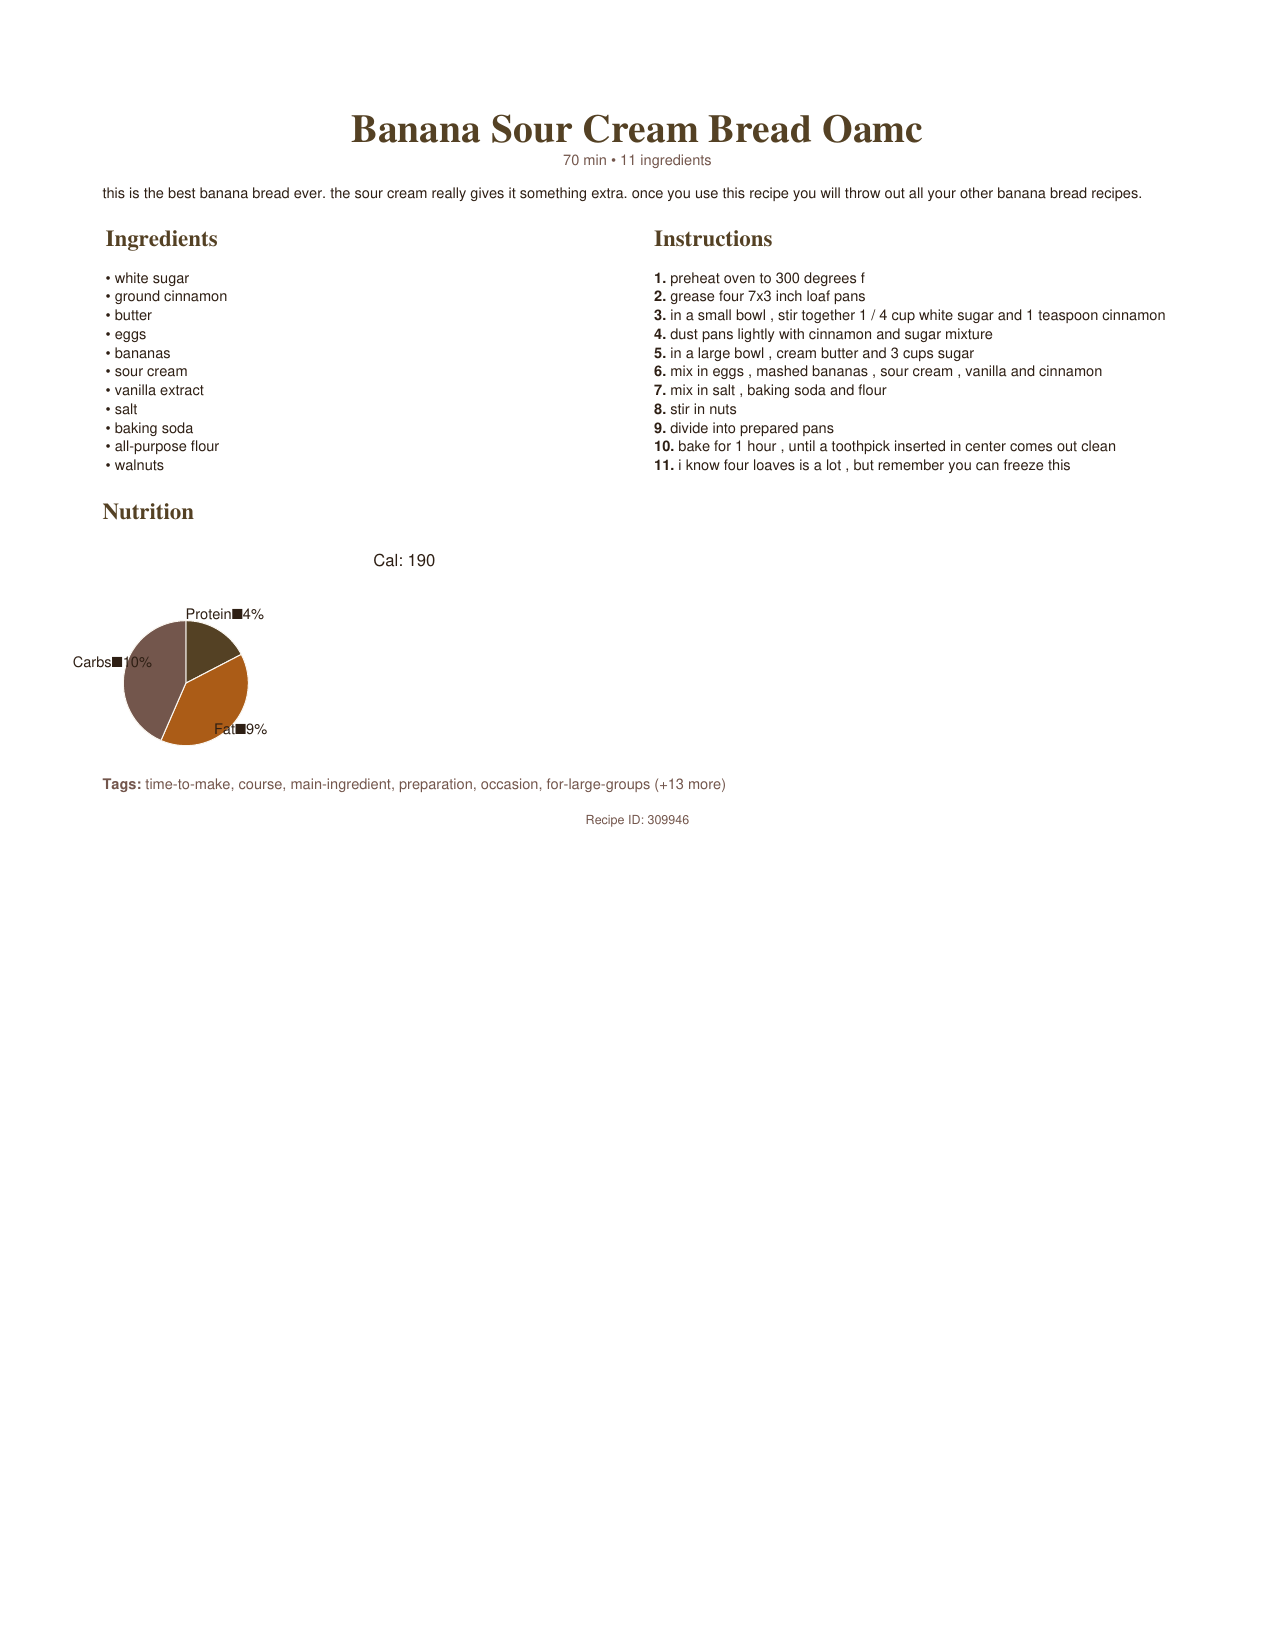
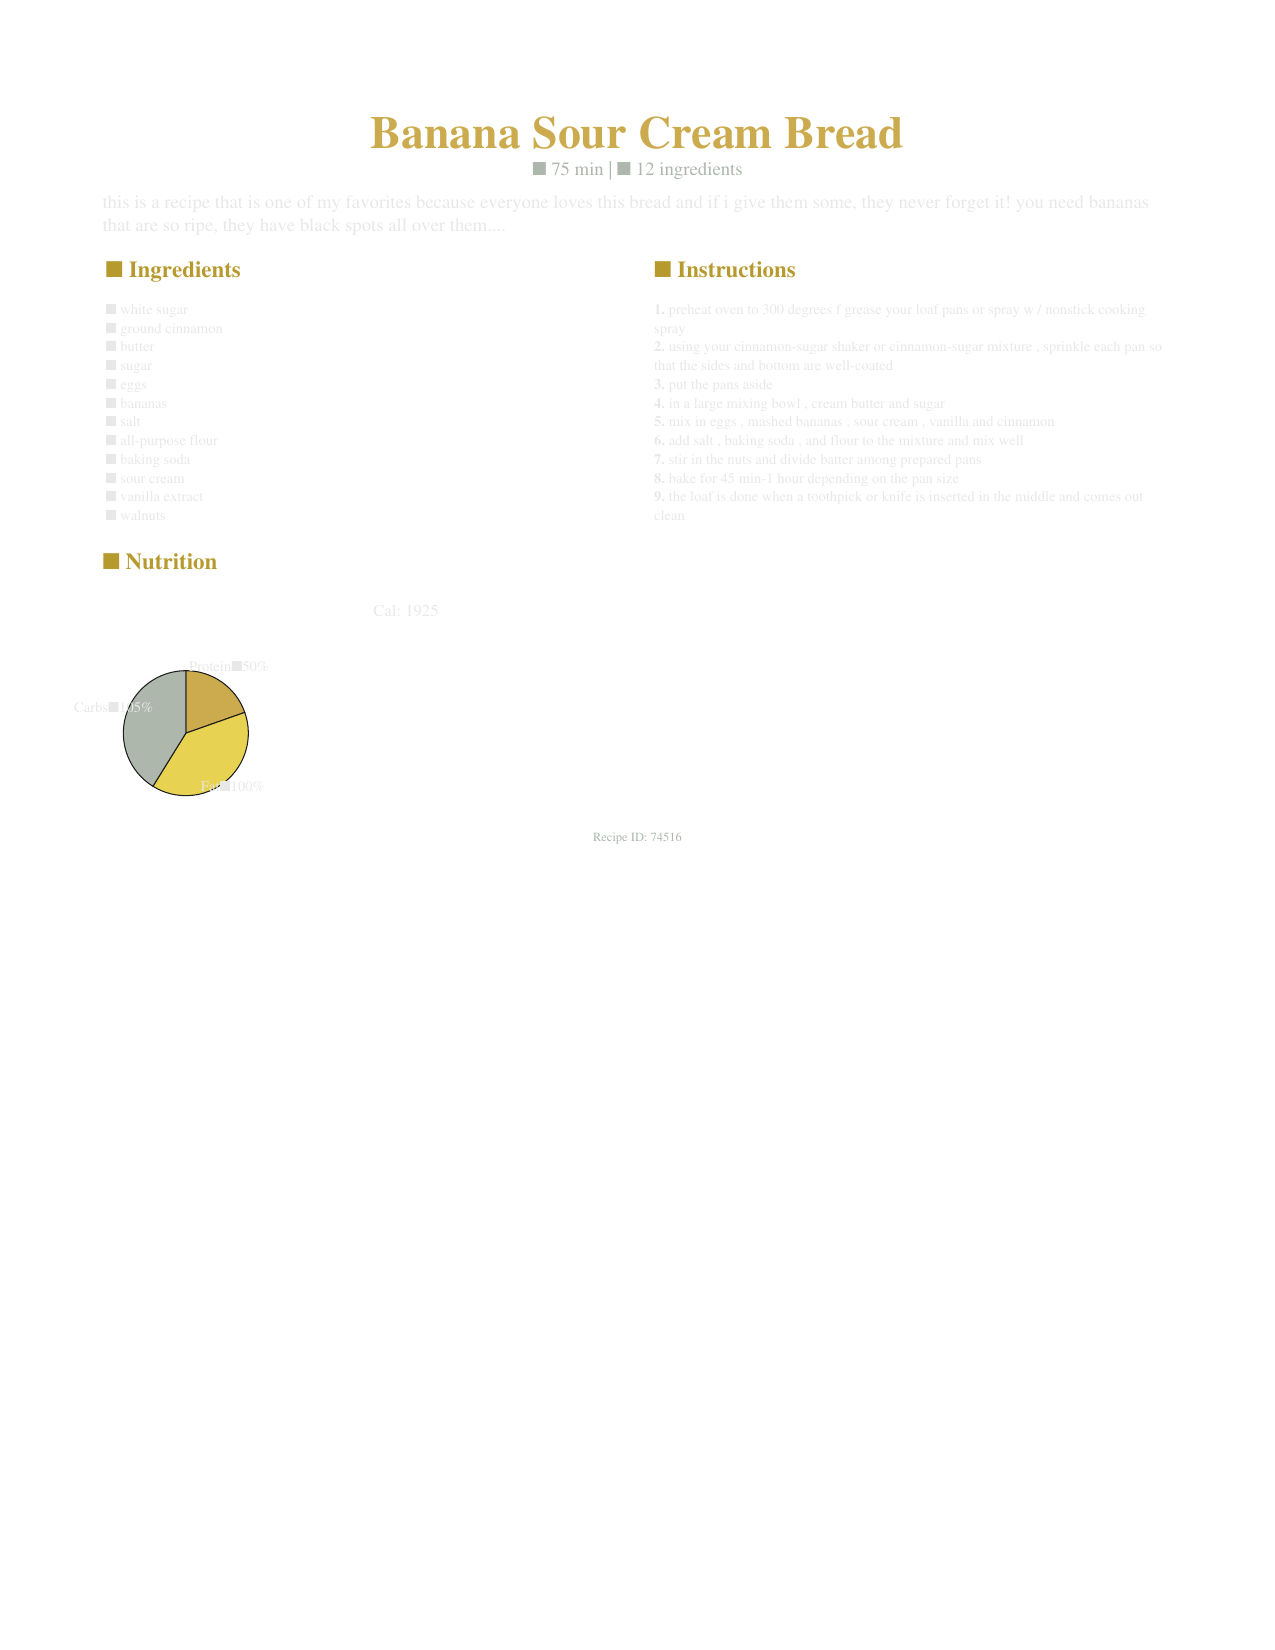
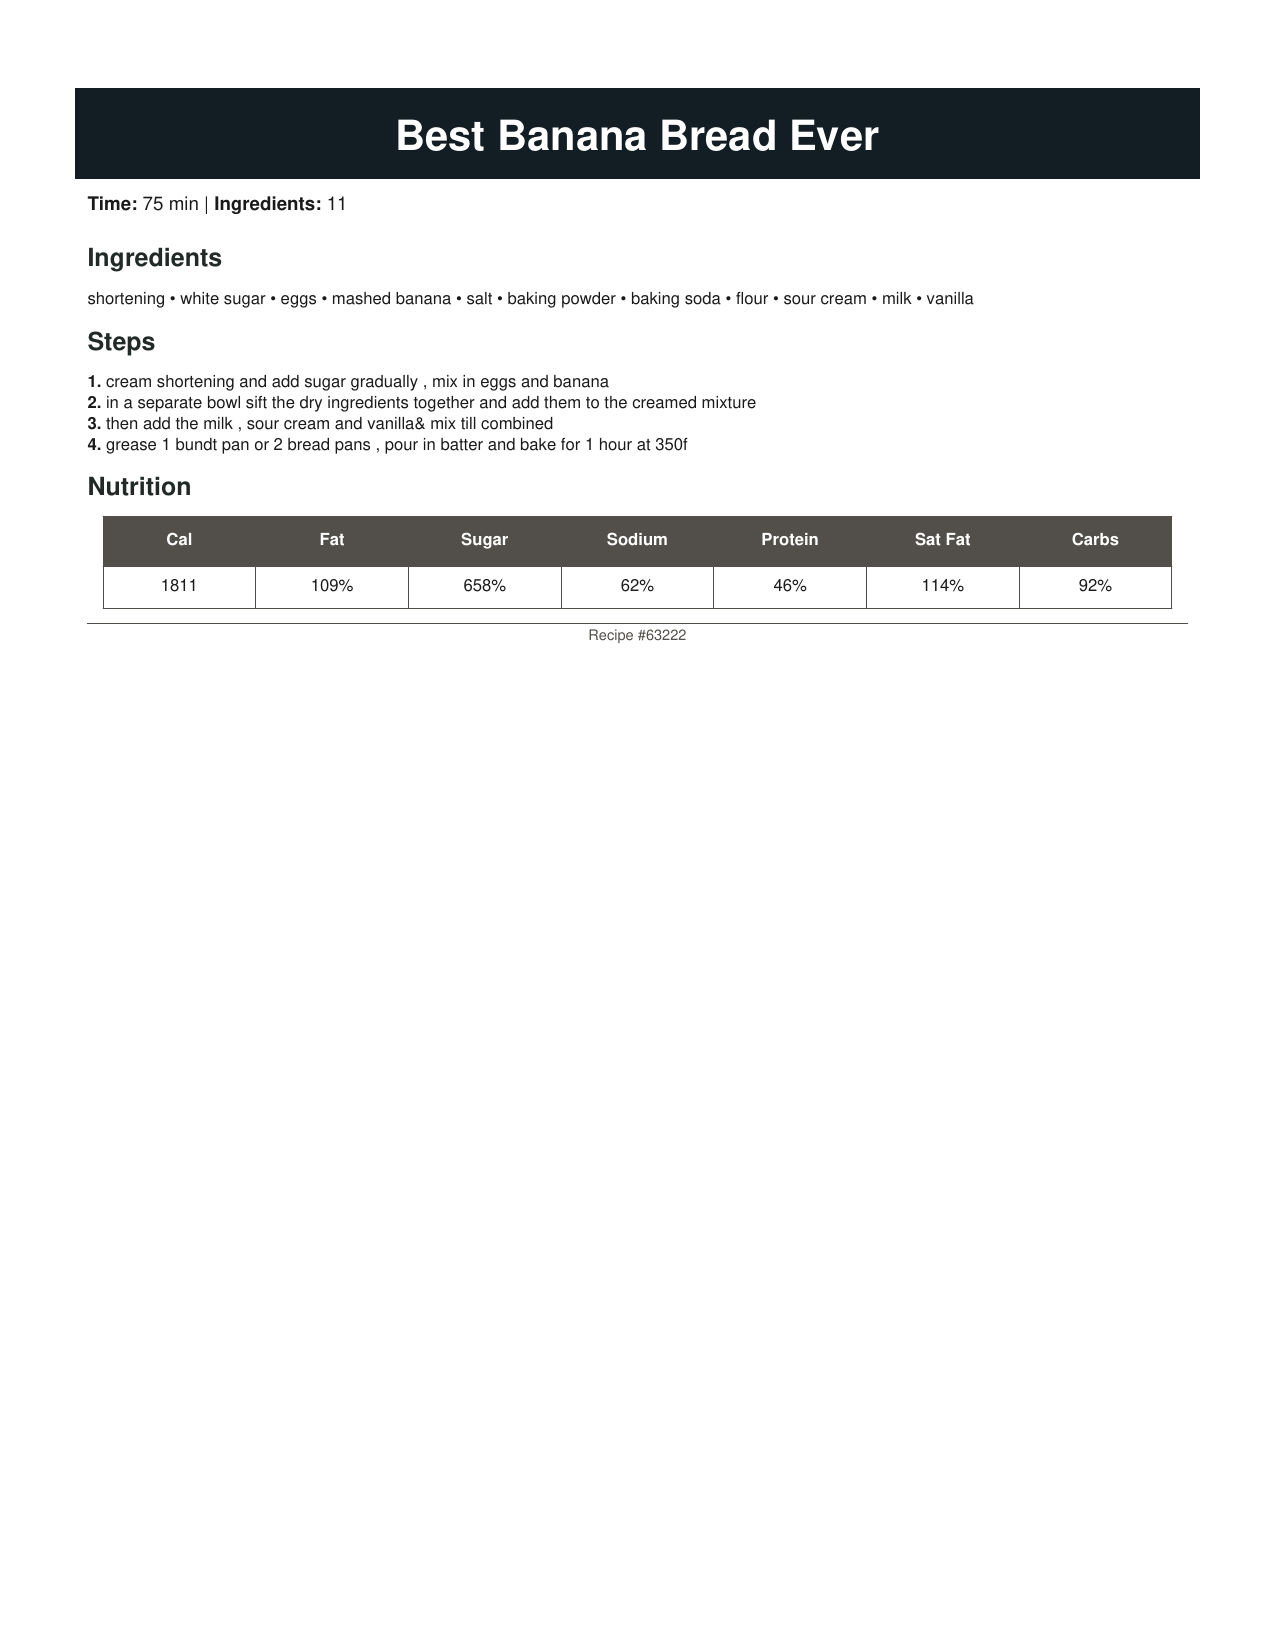
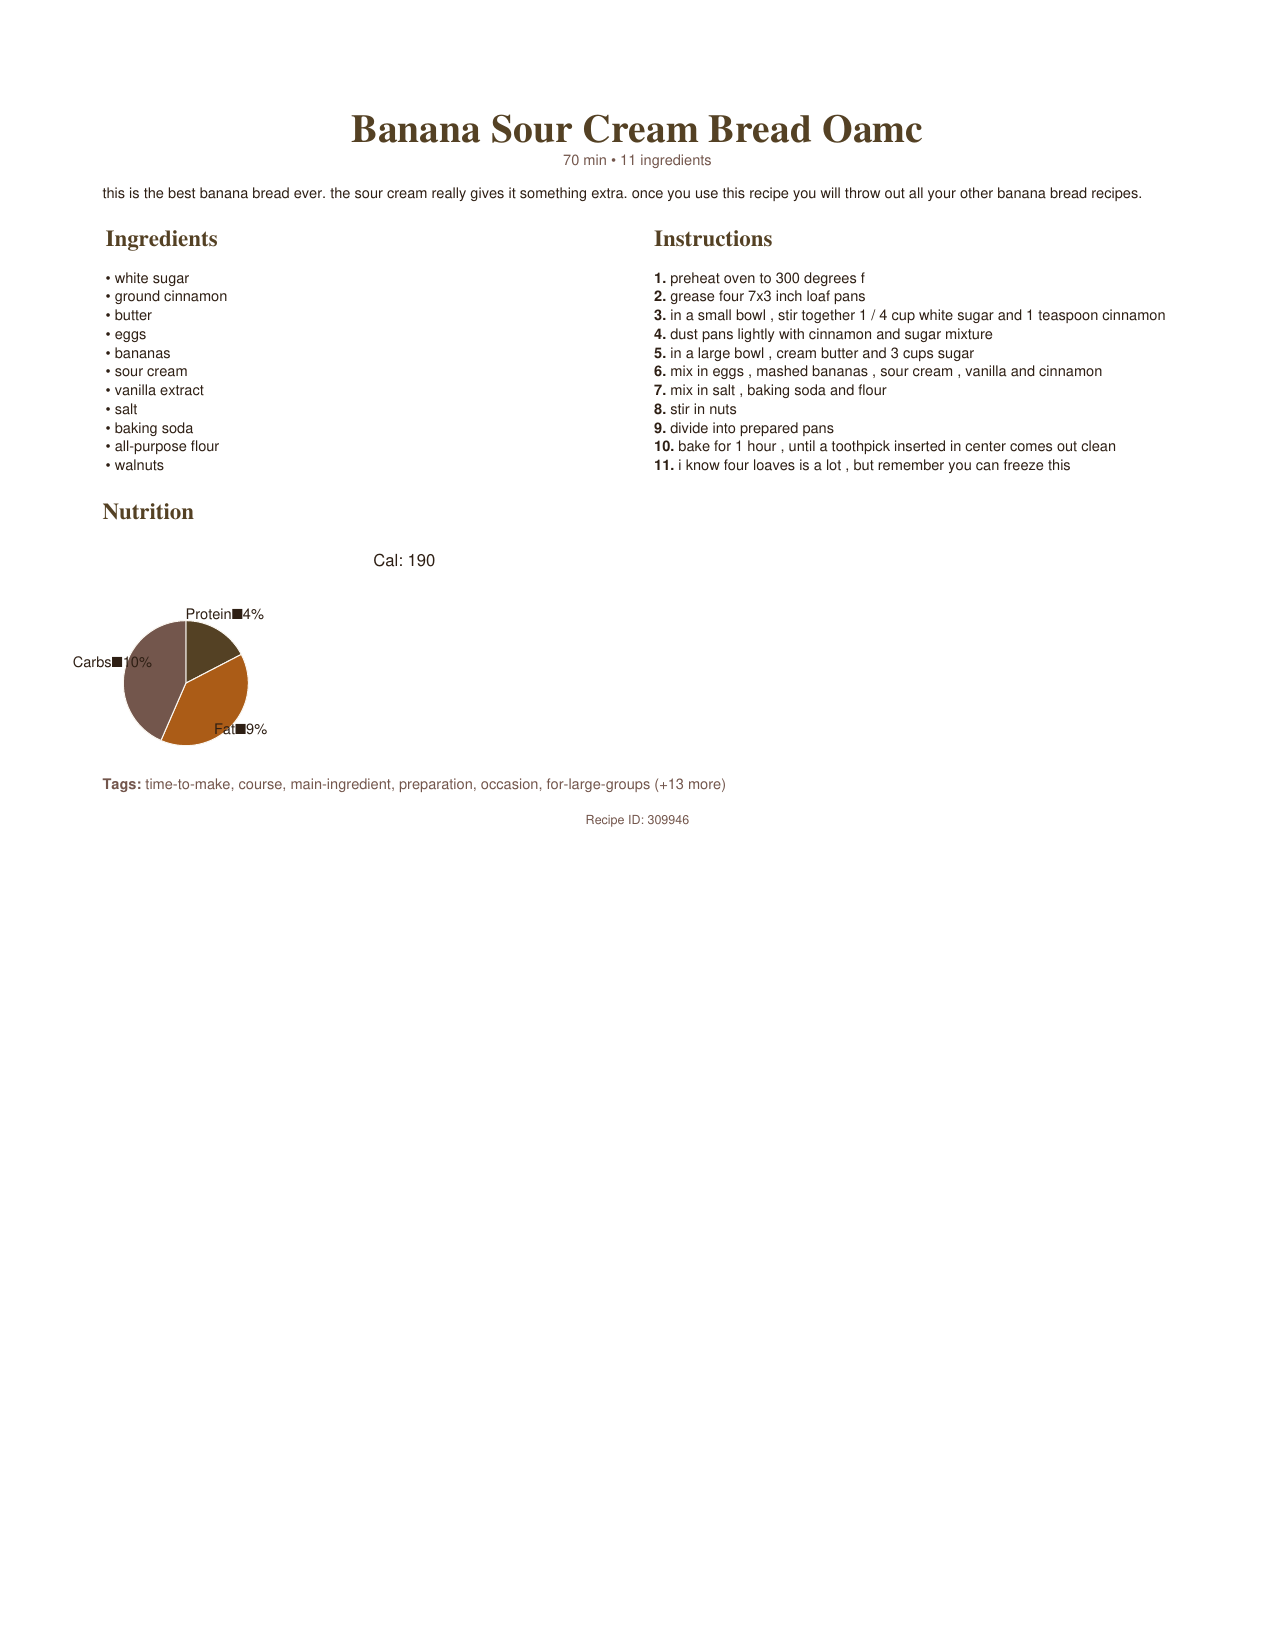
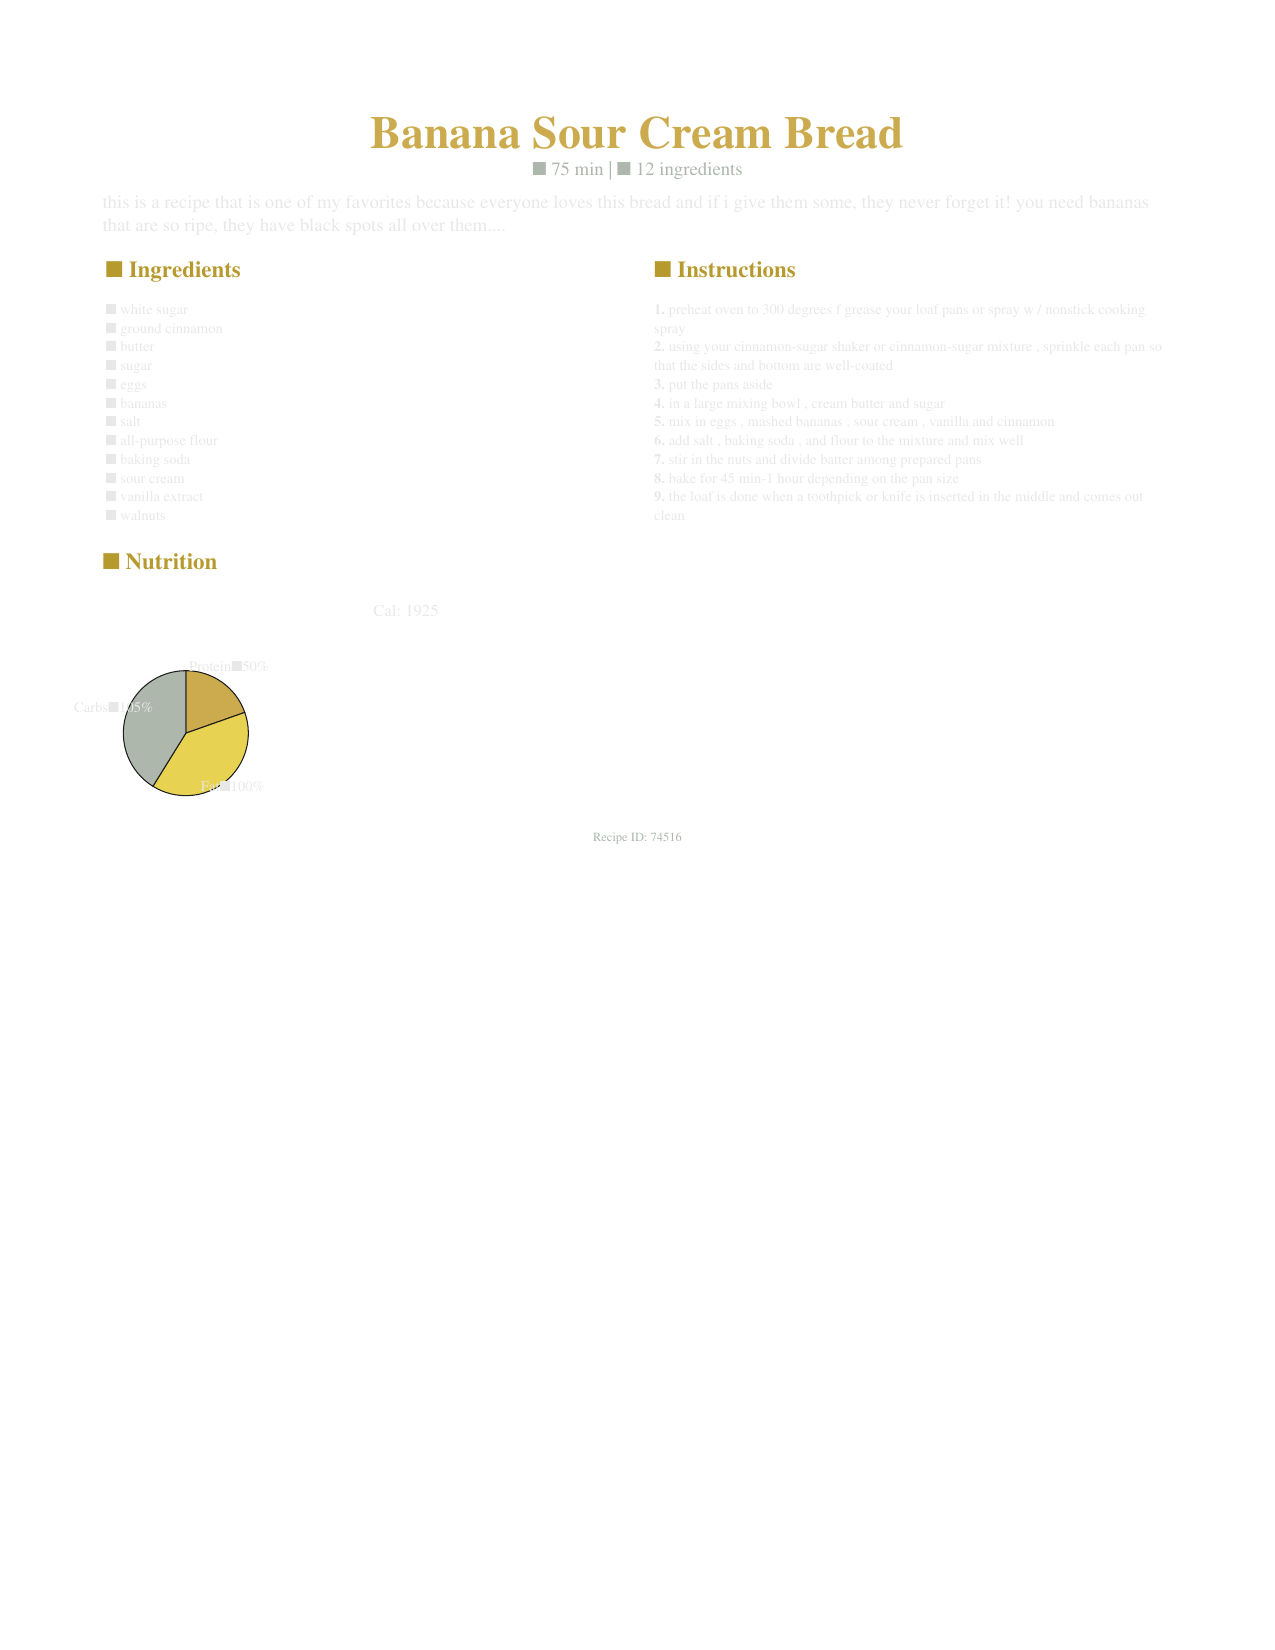
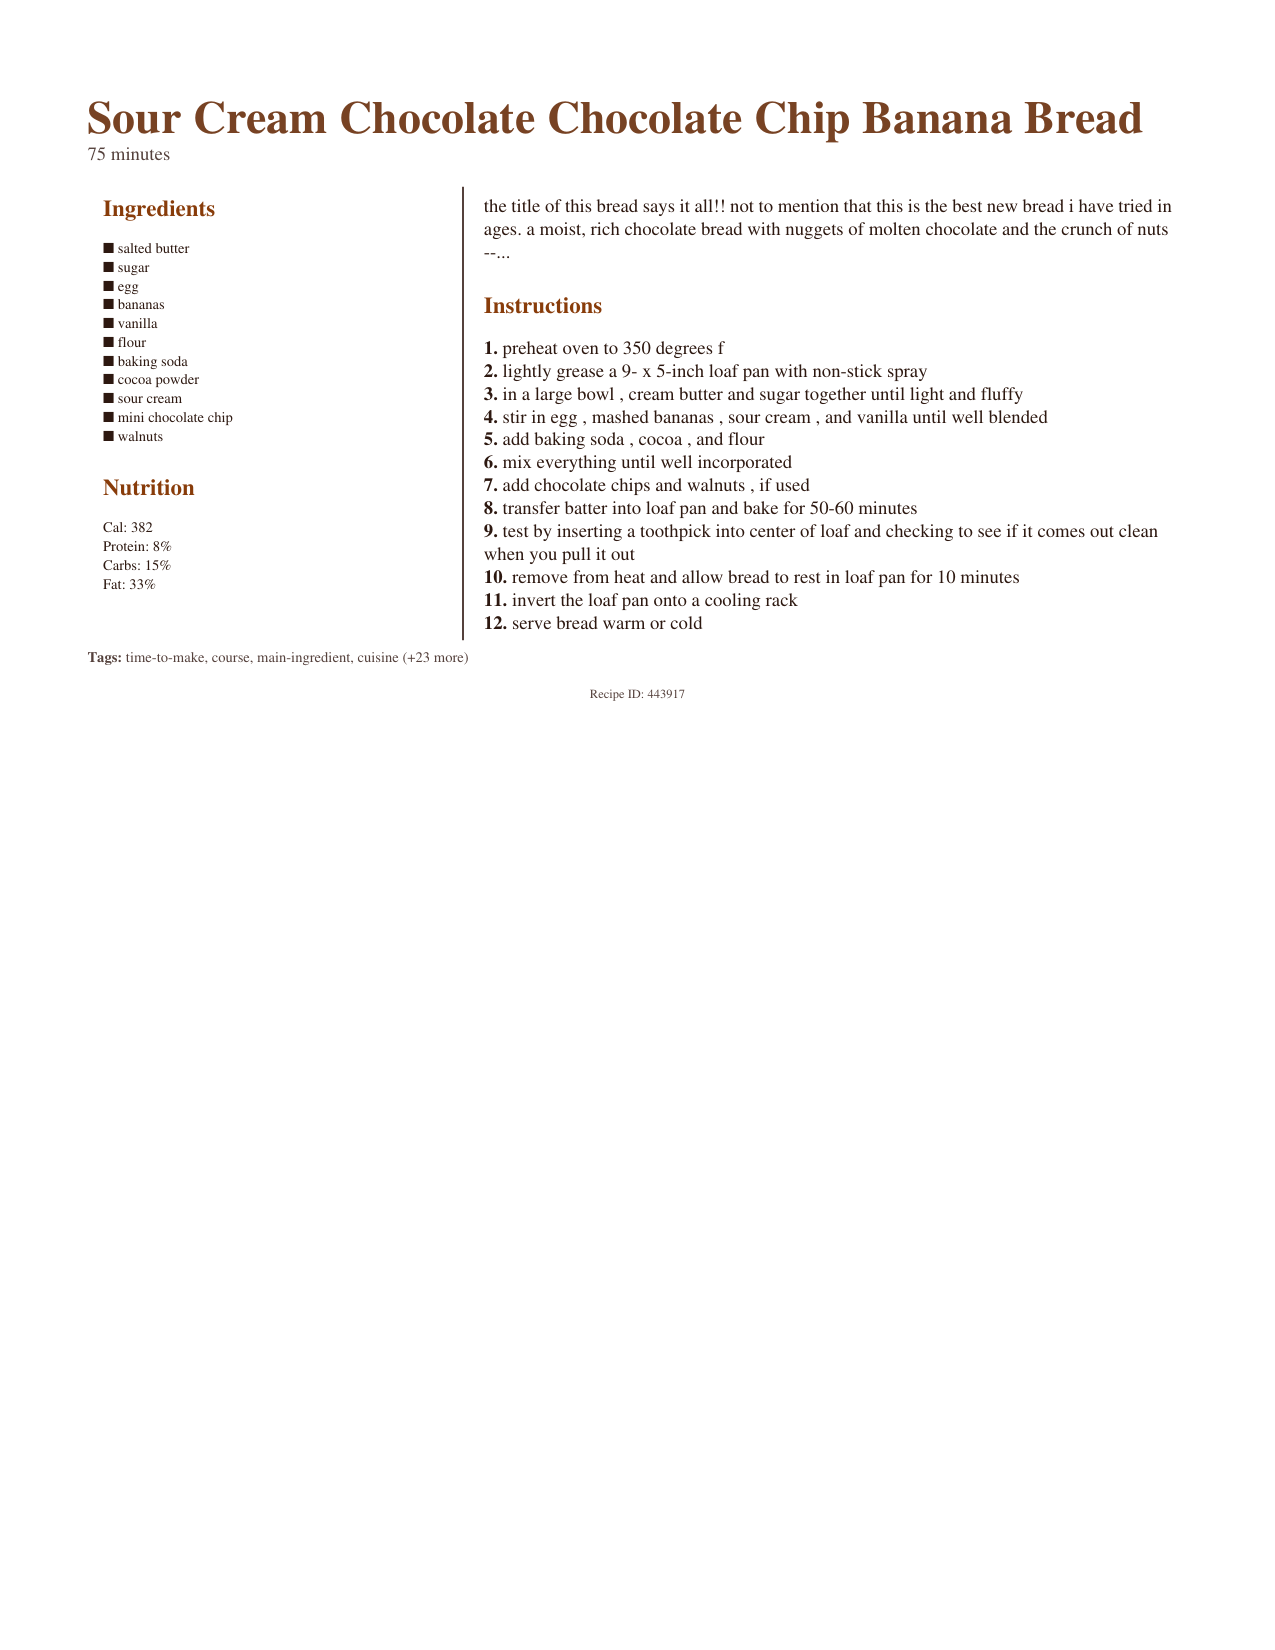

In [41]:
display_rerank_comparison(
    query=test_query_text,
    original_dataset=dataset_samples_to_rerank,   # Your original retrieval results
    reranked_dataset=dataset_samples_to_rerank.select(rerank_sorted_indicies),    # Your reranked results
    top_k=3
)

In our case, reranking took ~16 seconds to run on 20 image + text pairs.

Looking at the results, is reranking worth it?

This is something you will have to test and see if it fits your given circumstance.

## Load Generation Model

We are using `Qwen3-VL-2B-Instruct` for a small model as to not take up too much memory.

However, you could easily use a model such as [`nvidia/NVIDIA-Nemotron-3-Nano-30B-A3B-BF16](https://huggingface.co/nvidia/NVIDIA-Nemotron-3-Nano-30B-A3B-BF16) for higher quality outputs.

In [42]:
import torch
from transformers import Qwen3VLForConditionalGeneration, AutoProcessor

# Load Qwen3-VL-2B model and processor
GENERATION_MODEL_ID = "Qwen/Qwen3-VL-2B-Instruct"

qwen_model = Qwen3VLForConditionalGeneration.from_pretrained(
    GENERATION_MODEL_ID,
    dtype="auto",
    device_map="auto"
)

qwen_processor = AutoProcessor.from_pretrained(GENERATION_MODEL_ID)

print(f"[INFO] Loaded model: {GENERATION_MODEL_ID}")
print(f"[INFO] Device: {qwen_model.device}")

[INFO] Loaded model: Qwen/Qwen3-VL-2B-Instruct
[INFO] Device: cuda:0


### Create helper function for generating summaries

In [43]:
# Function to summarize recipes
def generate_recipe_summary(
    recipe_texts: list[str],
    model: Qwen3VLForConditionalGeneration = qwen_model,
    processor: AutoProcessor = qwen_processor,
    max_new_tokens: int = 512
) -> str:
    """
    Generate a markdown summary of multiple recipes.
    
    Args:
        recipe_texts: List of recipe markdown texts (up to 3)
        model: Loaded Qwen model
        processor: Loaded Qwen processor
        max_new_tokens: Maximum tokens to generate
    
    Returns:
        Markdown formatted summary of the recipes
    """
    # Combine recipes into numbered format
    recipes_combined = ""
    for i, recipe in enumerate(recipe_texts[:3], 1):
        recipes_combined += f"\n\n--- RECIPE {i} ---\n{recipe}"
    
    # Create the prompt
    prompt = f"""You are a helpful culinary assistant. Below are {len(recipe_texts[:3])} recipes. 
Please provide a brief markdown summary with:
- A short 1-2 sentence overview of each recipe
- Key ingredients highlighted
- Estimated difficulty (Easy/Medium/Hard)
- Which recipe might be best for a quick weeknight dinner

For example use the following format: 

```markdown
# Recipe summary

## <recipe_name>

[details]

## <recipe_name>

[details]

## <recipe_name>

[details]
```

Keep the summary concise and well-formatted in markdown. Return in ```markdown``` tags so it can be easily parsed.

<recipes>
{recipes_combined}
</recipes>

## Summary:"""

    # Format messages for Qwen
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "text", "text": prompt}
            ]
        }
    ]
    
    # Preparation for inference
    inputs = processor.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_dict=True,
        return_tensors="pt"
    )
    inputs = inputs.to(model.device)
    
    # Generate
    with torch.no_grad():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=0.7,
            top_p=0.9
        )
    
    # Decode - only the new tokens
    generated_ids_trimmed = [
        out_ids[len(in_ids):] 
        for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
    ]
    
    output_text = processor.batch_decode(
        generated_ids_trimmed,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False
    )[0]
    
    return output_text.strip()

# Generate an example summary
recipe_texts = list(dataset["train"].select([42, 43, 44])["recipe_markdown"])
summary = generate_recipe_summary(recipe_texts)
print(summary)

```markdown
# Recipe summary

## Artichoke Hearts Wrapped In Bacon

A quick and easy appetizer featuring artichoke hearts wrapped in crispy bacon, perfect for a weeknight dinner or casual gathering. Easy to prepare in under 15 minutes, it's a delicious, low-carb option with a satisfying crunch and bold flavor. **Key ingredients:** bacon, artichokes. **Difficulty:** Easy. **Best for:** quick weeknight dinner.

## Avocados Stock Up On Sale And Freeze Tips Oamc

A simple and cost-effective tip for preserving avocados during sales. By freezing mashed avocados with lemon juice, you can enjoy them year-round. It's a 2-minute prep method that's perfect for busy weeknights. **Key ingredients:** avocado, lemon juice. **Difficulty:** Easy. **Best for:** weeknight meal prep, quick snack.

## Award Winning Pineapple Preserves

A simple, two-ingredient recipe for homemade pineapple preserves that's easy to make and perfect for canning. With a thick consistency and sweet flavor, it's ideal for desse

## Make a Gradio demo

Let's turn our retrieval pipeline into a demo so other people can try it out.

Ideally our demo will: 

* Enable someone to input text/image
* Retrieve results and display
* Optional: enable reranking
* Display time/latency throughout

In [49]:
# Match the input query to the target embeddings and get back scores and indices
print(f"[INFO] Finding recipe matches on query: {query}")
result_sorted_scores, result_sorted_indices = match_query_to_embeddings(query=query,
                                                                        target_embeddings_to_match=image_text_embeddings,
                                                                        top_k=100) # get back the top 100 samples

[INFO] Finding recipe matches on query: recipes with tomato and parmesan cheese


In [50]:
display_rerank_changes(rerank_sorted_indicies)

Rank   Sample   Original   Change    
------------------------------------
1      #0       was #1       —         
2      #1       was #2       —         
3      #7       was #8       ↑5        
4      #6       was #7       ↑3        
5      #8       was #9       ↑4        
6      #2       was #3       ↓3        
7      #3       was #4       ↓3        
8      #11      was #12      ↑4        
9      #13      was #14      ↑5        
10     #18      was #19      ↑9        
11     #5       was #6       ↓5        
12     #14      was #15      ↑3        
13     #17      was #18      ↑5        
14     #4       was #5       ↓9        
15     #9       was #10      ↓5        
16     #19      was #20      ↑4        
17     #15      was #16      ↓1        
18     #10      was #11      ↓7        
19     #12      was #13      ↓6        
20     #16      was #17      ↓3        


### Create a helper function for showing recipe texts

Our helper fucntion will convert our recipes as markdown into HTML for displaying in our Gradio demo.

In [ ]:
import time

def create_recipe_cards_html(
    scores_and_samples: list[dict],
    num_results: int = 3,
    text_key: str = "text",
    max_reviews: int = 1
) -> str:
    """
    Generate combined HTML cards from scored recipe samples.
    
    Args:
        scores_and_samples: List of dicts with "sample" key containing recipe data
        num_results: Number of recipe cards to generate
        text_key: Key to extract markdown text from sample (tries this, then "markdown")
        max_reviews: Maximum number of reviews to show per card
    
    Returns:
        Combined HTML string with title and recipe cards in a 3-column row
    """
    recipe_cards_html = []
    
    for item in scores_and_samples[:num_results]:
        sample = item["sample"]
        markdown_text = sample.get(text_key, "") or sample.get("markdown", "")
        card_html = _markdown_to_simple_html(markdown_text, max_reviews=max_reviews)
        recipe_cards_html.append(f'<div style="flex: 1; min-width: 0;">{card_html}</div>')
    
    combined_html = f'''
    <div style="margin-top: 16px;">
        <h3 style="font-family: system-ui, -apple-system, sans-serif; font-size: 16px; font-weight: 600; color: #333; margin-bottom: 12px;">Retrieved Texts</h3>
        <div style="display: flex; flex-direction: row; gap: 12px; width: 100%;">
            {"".join(recipe_cards_html)}
        </div>
    </div>
    '''
    
    return combined_html


### Create a function to perform our RAG pipeline

We'll make a single function to go from input (text/image) -> retrieval -> rerank (optional) -> generate (optional) -> display results.

This is because Gradio works off the premise of input -> function -> output.

Our input will be a text/image query for recipes, our function will perform the RAG pipeline steps and return our desired outputs to display.

In [51]:
def retrieve(query_text: str | None,
             query_image: Image.Image | None,
             rerank_option: str,
             generate_summary_option: str):
    
    # If both query_text and query_image exist, default to query_text
    # Favour query_text if both exist
    if query_text and query_text.strip():  # Handles None, "", and whitespace
        input_query = query_text
    elif query_image is not None:
        input_query = query_image
    else:
        raise ValueError("Please provide either a text query or an image query.")
    
    print(f"[INFO] Query image: {query_image}")
    print(f"[INFO] Query text: {query_text}")
    print(f"[INFO] Input query: {input_query}")
    
    ### Retrieval steps ### 

    # Embed query text or image + Match query text or image to embeddings
    start_time_query_to_embed_match = time.time()
    result_sorted_scores, result_sorted_indices = match_query_to_embeddings(query=input_query,
                                                                            target_embeddings_to_match=image_text_embeddings,
                                                                            top_k=20) # get back the top 20 samples
    end_time_query_to_embed_match = time.time()

    # Return the results ready for displaying
    top_dataset_results_to_show = dataset["train"].select(result_sorted_indices)

    # Collate the scores and samples
    scores_and_samples = []
    for score, sample in zip(result_sorted_scores, top_dataset_results_to_show):
        scores_and_samples.append({"score": round(score.item(), 4), "sample": sample})
    
    # Create image gallery in format list of (image, caption) or in our case (image, score)
    output_image_gallery = [(item["sample"]["image"], str(f'Score: {item["score"]}')) for item in scores_and_samples[:3]]

    # Create output texts
    output_recipe_cards_html = create_recipe_cards_html(
        scores_and_samples=scores_and_samples,
        num_results=3,
        text_key="recipe_markdown", 
        max_reviews=1
    )

    ### Reranking steps ### 

    # Optional: Rerank the results
    if rerank_option == "True":
        print(f"[INFO] Rerank option set to: {rerank_option}, performing reranking...")
        start_time_reranking = time.time()
        dataset_samples_to_rerank, rerank_sorted_indicies= rerank_samples(sorted_indices=result_sorted_indices,
                                                                                    dataset=dataset,
                                                                                    dataset_split="train",
                                                                                    query_text=input_query,
                                                                                    num_samples_to_rerank=20, 
                                                                                    rerank_model=rerank_model, 
                                                                                    rerank_processor=rerank_processor)
        end_time_reranking = time.time()
        rerank_time = round(end_time_reranking - start_time_reranking, 4)

        # Make the collated samples 
        top_dataset_results_to_show = dataset_samples_to_rerank.select(rerank_sorted_indicies)
        samples_and_rerank_changes = []
        for new_rank, (sample, original_rank) in enumerate(zip(top_dataset_results_to_show, rerank_sorted_indicies)):
            movement = new_rank - original_rank
            if movement == 0:
                movement_string = f"{movement}"
            else:
                movement_string = f"+{abs(movement)}" if movement < 0 else f"-{movement}"
            rerank_string = f"Original rank: {original_rank} | New rank: {new_rank} | Movement: {movement_string}"
            samples_and_rerank_changes.append({"sample": sample, "rerank_string": rerank_string})

        # Create outputs
        output_image_gallery = [(item["sample"]["image"], item["rerank_string"]) for item in samples_and_rerank_changes[:3]]
        output_recipe_cards_html = create_recipe_cards_html(
            scores_and_samples=samples_and_rerank_changes,
            num_results=3,
            text_key="recipe_markdown", 
            max_reviews=1
        )
    else:
        print(f"[INFO] Rerank option set to: {rerank_option}, skipping reranking...")
        rerank_time = "Reranking turned off"

    ### Generation steps ### 

    # Optional: Generate summary of recipes in markdown
    if generate_summary_option == "True":
        print(f"[INFO] Generation summary option set to: {generate_summary_option}, generating summary...")
        start_time_generation_output = time.time()
        if rerank_option == "True":
            recipe_texts = [item["sample"]["recipe_markdown"] for item in samples_and_rerank_changes[:3]]
            summary = generate_recipe_summary(recipe_texts)
            summary = summary.replace("```markdown", "").replace("```", "")
        else:
            recipe_texts = [item["sample"]["recipe_markdown"] for item in scores_and_samples[:3]]
            summary = generate_recipe_summary(recipe_texts)
            summary = summary.replace("```markdown", "").replace("```", "")
        end_time_generation_output = time.time()
        generation_time = round(end_time_generation_output - start_time_generation_output, 4)
    else:
        print(f"[INFO] Generation summary option set to: {generate_summary_option}, skipping summary...")
        generation_time = "Generation turned off"
        summary = "Generation turned off, no summary created"
    
    # Make timing dict to track latency
    timing_dict = {"query_embed_and_match_time": round(end_time_query_to_embed_match - start_time_query_to_embed_match, 4),
                   "rerank_time": rerank_time,
                   "generation_time": generation_time}

    # Want to return the outputs we'd like to show in our Graido demo 
    return output_image_gallery, output_recipe_cards_html, summary, timing_dict

In [59]:
demo_test_query = "cup of tea"
output_image_gallery, output_recipe_cards_html, summary, timing_dict = retrieve(query_text=demo_test_query,
                                                                                query_image=None,
                                                                                rerank_option="False",
                                                                                generate_summary_option="True")

print(f"\n[INFO] Timing dict: {timing_dict}\n")

[INFO] Query image: None
[INFO] Query text: cup of tea
[INFO] Input query: cup of tea
[INFO] Rerank option set to: False, skipping reranking...
[INFO] Generation summary option set to: True, generating summary...

[INFO] Timing dict: {'query_embed_and_match_time': 0.0294, 'rerank_time': 'Reranking turned off', 'generation_time': 8.3803}



In [60]:
print(f"[INFO] Summary text for recipes retrieved with query: {demo_test_query}")
print(summary)

[INFO] Summary text for recipes retrieved with query: cup of tea

# Recipe summary

## Clove And Cinnamon Tea

A warm, aromatic tea made with clove, cinnamon, tea leaves, sugar, and milk. Easy to make in under 10 minutes, perfect for a cozy, comforting drink.  
**Key ingredients**: clove, cinnamon, tea leaves, sugar, milk  
**Difficulty**: Easy  
**Best for**: Quick weeknight dinner

## Spiced Chai Concentrate

A rich, spiced chai concentrate made with cinnamon, ginger, cardamom, star anise, cloves, and tea, with optional sweeteners. Can be frozen and used in drinks or hot.  
**Key ingredients**: cinnamon, ginger, cardamom, star anise, cloves, black tea, brown sugar, honey, vanilla  
**Difficulty**: Easy  
**Best for**: Quick weeknight dinner

## Afghan Tea

A simple, warming tea made with milk, cardamom, tea bags, and sugar. Easy to prepare in just 7 minutes, ideal for a sweet, creamy, and comforting drink.  
**Key ingredients**: whole milk, green cardamom pods, tea bags, sugar  
**Di

We can display the retrieved texts as HTML cards.

In [61]:
display(HTML(output_recipe_cards_html))

And we can create a helper function to make the retrieved images viewable in a gallery style.

[INFO] Showing images retrieved for query: cup of tea


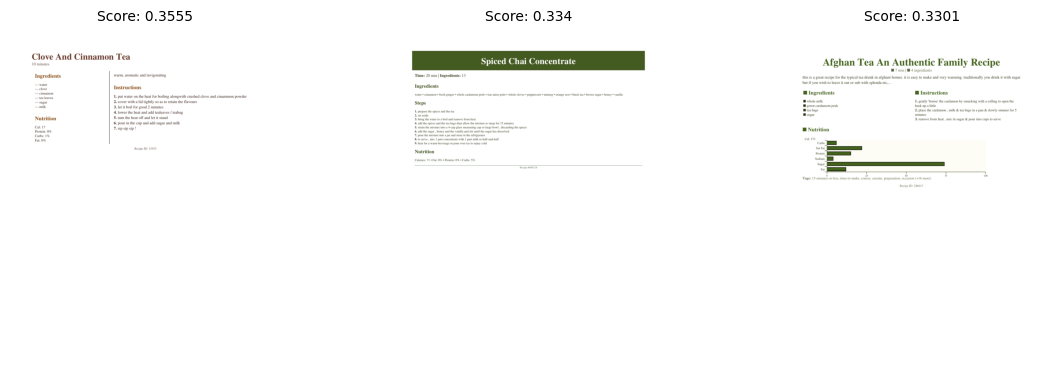

In [62]:
import matplotlib.pyplot as plt
from typing import List, Tuple
from PIL import Image

print(f'[INFO] Showing images retrieved for query: {demo_test_query}')

def plot_image_gallery(
    images: List[Tuple[Image.Image, str]],
    cols: int = 3,
    figsize: Tuple[int, int] = None,
    fontsize: int = 10
) -> None:
    """
    Plot a gallery of PIL images with captions.
    
    Args:
        images: List of (PIL.Image, caption_string) tuples
        cols: Number of columns in the grid
        figsize: Figure size as (width, height). Auto-calculated if None.
        fontsize: Font size for titles
    """
    n_images = len(images)
    rows = (n_images + cols - 1) // cols  # Ceiling division
    
    if figsize is None:
        figsize = (4 * cols, 4 * rows)
    
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    
    # Handle single row/col case
    if n_images == 1:
        axes = [[axes]]
    elif rows == 1:
        axes = [axes]
    elif cols == 1:
        axes = [[ax] for ax in axes]
    
    for idx, (img, caption) in enumerate(images):
        row, col = divmod(idx, cols)
        ax = axes[row][col]
        ax.imshow(img)
        ax.set_title(caption, fontsize=fontsize, wrap=True)
        ax.axis('off')
    
    # Hide empty subplots
    for idx in range(n_images, rows * cols):
        row, col = divmod(idx, cols)
        axes[row][col].axis('off')
    
    plt.tight_layout()
    plt.show()

plot_image_gallery(output_image_gallery)

### Build the Gradio demo

We can now run construct and run our Gradio demo inside our notebook if we like.

In [63]:
import gradio as gr

with gr.Blocks(
    title="Multimodal RAG Demo",
) as demo:
    gr.Markdown("""# 👁️📑 Multimodal RAG Demo with Nemotron Embed VL and Rerank VL
                
                Input an image or text about food and get recipe images/text back.

                This is a scalable workflow that can lend itself to many use cases such as business document retrieval, technical manual look ups and more.

                By default it returns the top 3 results from a database of 10,000+ recipes. We've limited it to 3 for the demo but in practice you could return as many as you like.
                
                * **Dataset used:** https://huggingface.co/datasets/mrdbourke/recipe-synthetic-images-10k
                * **Embedding model used:** https://huggingface.co/nvidia/llama-nemotron-embed-vl-1b-v2
                    * **Note:** By default we use the image + text embeddings as we have access to image and text pairs in our dataset, and according to the [launch blog post](https://huggingface.co/blog/nvidia/llama-nemotron-vl-1b), these work the best.
                * **Rerank model used:** https://huggingface.co/nvidia/llama-nemotron-rerank-vl-1b-v2
                * **Generation model used:** https://huggingface.co/Qwen/Qwen3-VL-2B-Instruct (note: you could use a larger model such as [Nemotron v3](https://huggingface.co/collections/nvidia/nvidia-nemotron-v3), however, this will require more compute resources)
                
                """)
    
    with gr.Row():
        with gr.Column(scale=1):
            gr.Markdown("### Query Input")

            query_text = gr.Textbox(
                label="Text Query",
                placeholder="e.g. 'dinner recipes with tomatoes'",
                lines=2
            )

            query_image = gr.Image(
                label="Image Query (optional)",
                type="pil",
                height=200
            )

            generate_summary_option = gr.Radio(
                choices=["True", "False"],
                value="False",
                label="Generate recipe summary"
            )

            rerank_option = gr.Radio(
                choices=["True", "False"],
                value="False",
                label="Rerank initial results? (note: reranking is for text queries only)"
            )

            search_btn = gr.Button("Search", variant="primary", size="lg")
        
        with gr.Column(scale=2):
            gr.Markdown("### Retrieved Results")

            gallery_output = gr.Gallery(
                label="Retrieved Recipe Images",
                columns=3, 
                height="auto",
                object_fit="cover",
                show_label=True
            )

            recipes_html = gr.HTML(label="Retrieved Recipe Texts")

            summary_generation = gr.Markdown(
                label="Retrieved Recipe Summary (generated from top results)"
            )

            timing_dict = gr.JSON(
                label="Timings",
            )
    
    gr.Markdown("### Example Queries")

    # Create examples
    gr.Examples(
        examples=[
            ["best omelette recipes", None, "False", "False"],
            ["best omelette recipes", None, "False", "True"],
            ["best omelette recipes", None, "True", "True"],
            ["eggplant dip", None, "True", "True"],
            [None, "kitchen_bench.png", "False", "True"]
        ],
        inputs=[query_text, query_image, rerank_option, generate_summary_option],  # Must match the input components
        label="Example Queries"
    )

    search_btn.click(
        fn=retrieve,
        inputs=[query_text, query_image, rerank_option, generate_summary_option],
        outputs=[gallery_output, recipes_html, summary_generation, timing_dict]
    )

demo.launch(
    share=False,
    debug=True,
    inline=True, 
    show_error=True,
    height=1000
)

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


Keyboard interruption in main thread... closing server.


## Turn the Gradio demo into files 

We can turn our Gradio demo into a series of files we can upload to Hugging Face Spaces to make it live.

Specifically we'll need:

* `app.py` - Main entry file for the application to start.
* `requirements.txt` - Requirements for our Space to install.
* `README.md` - Details about our app and how it works as well as metadata about the Space.

In [64]:
!mkdir -p demo

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


### Create the `app.py` file

In [65]:
%%writefile demo/app.py
"""
Multimodal RAG Demo with Nemotron Embed VL and Rerank VL

A Gradio demo for multimodal retrieval augmented generation using:
- Dataset: mrdbourke/recipe-synthetic-images-10k
- Embedding model: nvidia/llama-nemotron-embed-vl-1b-v2
- Rerank model: nvidia/llama-nemotron-rerank-vl-1b-v2
- Generation model: Qwen/Qwen3-VL-2B-Instruct
"""

import spaces
import time
import torch
import gradio as gr
from PIL import Image
from datasets import load_dataset
from safetensors.torch import load_file
from transformers import (
    AutoModel,
    AutoModelForSequenceClassification,
    AutoProcessor,
    Qwen3VLForConditionalGeneration,
)

# ============================================================================
# Configuration
# ============================================================================

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Model paths and commit hashes (required for sdpa attention on HF Spaces)
EMBED_MODEL_PATH = "nvidia/llama-nemotron-embed-vl-1b-v2"
EMBED_COMMIT_HASH = "5b5ca69c35bf6ec1484d2d5ff238626e67a745e2"

RERANK_MODEL_PATH = "nvidia/llama-nemotron-rerank-vl-1b-v2"
RERANK_COMMIT_HASH = "47e5a355d1a050c3e5f69d53f14964b1d34bcd9d"

GENERATION_MODEL_ID = "Qwen/Qwen3-VL-2B-Instruct"

# ============================================================================
# Load Dataset and Embeddings
# ============================================================================

print("[INFO] Loading dataset...")
dataset = load_dataset(path="mrdbourke/recipe-synthetic-images-10k")
print(f"[INFO] Dataset loaded with {len(dataset['train'])} samples")

print("[INFO] Loading embeddings...")
image_text_embeddings = load_file("image_text_embeddings_10k.safetensors")
# Note: Load embeddings to CPU first and then move them to GPU *inside* the retrieve function to
# make use of the @spaces.GPU decorator.
image_text_embeddings = image_text_embeddings["image_text_embeddings"]
print(f"[INFO] Embeddings loaded: {image_text_embeddings.shape}")

# ============================================================================
# Load Models
# ============================================================================
modality_to_tokens = {
    "image": 2048,
    "image_text": 10240,
    "text": 8192
}

print(f"[INFO] Loading embedding model from: {EMBED_MODEL_PATH} with commit: {EMBED_COMMIT_HASH}")
embed_model = AutoModel.from_pretrained(
    EMBED_MODEL_PATH,
    revision=EMBED_COMMIT_HASH,
    dtype=torch.bfloat16,
    trust_remote_code=True,
    attn_implementation="sdpa",
    device_map="auto",
).eval()

# Set embed processor kwargs
# Note: These are the suggest settings from the embed model card
embed_modality = "image_text"
embed_processor_kwargs = {
    "max_input_tiles": 6,
    "use_thumbnail": True,
    "p_max_length": modality_to_tokens[embed_modality]
}

embed_processor = AutoProcessor.from_pretrained(
    EMBED_MODEL_PATH,
    revision=EMBED_COMMIT_HASH,
    trust_remote_code=True,
    **embed_processor_kwargs
)
print(f"[INFO] Embedding model loaded!")
print(f"[INFO] Embed processor using p_max_length: {embed_processor.p_max_length}")

print(f"[INFO] Loading rerank model from: {RERANK_MODEL_PATH} with commit: {RERANK_COMMIT_HASH}")
rerank_model = AutoModelForSequenceClassification.from_pretrained(
    RERANK_MODEL_PATH,
    revision=RERANK_COMMIT_HASH,
    dtype=torch.bfloat16,
    trust_remote_code=True,
    attn_implementation="sdpa",
    device_map="auto",
).eval()

# Set rerank processor kwargs
# Note: These are the suggest settings from the rerank model card
rerank_modality = "image_text"
rereank_processor_kwargs = {
    "max_input_tiles": 6,
    "use_thumbnail": True,
    "rerank_max_length": modality_to_tokens[rerank_modality]
}

rerank_processor = AutoProcessor.from_pretrained(
    RERANK_MODEL_PATH,
    revision=RERANK_COMMIT_HASH,
    trust_remote_code=True,
    **rereank_processor_kwargs
)
print(f"[INFO] Rerank processor using rerank_max_length: {rerank_processor.rerank_max_length}")

print(f"[INFO] Rerank model loaded!")

print("[INFO] Loading generation model...")
qwen_model = Qwen3VLForConditionalGeneration.from_pretrained(
    GENERATION_MODEL_ID,
    dtype="auto",
    device_map="auto"
)
qwen_processor = AutoProcessor.from_pretrained(GENERATION_MODEL_ID)
print(f"[INFO] Generation model loaded")

# ============================================================================
# Helper Functions
# ============================================================================

def _l2_normalize(x: torch.Tensor, eps: float = 1e-12) -> torch.Tensor:
    """L2 normalize a tensor along the last dimension."""
    return x / (x.norm(p=2, dim=-1, keepdim=True) + eps)


def match_query_to_embeddings(
    query: str | Image.Image,
    target_embeddings_to_match: torch.Tensor,
    top_k: int = 100
) -> tuple[torch.Tensor, torch.Tensor]:
    """
    Match a query (text or image) to target embeddings.
    
    Returns:
        Tuple of (sorted_scores, sorted_indices)
    """
    with torch.inference_mode():
        if isinstance(query, Image.Image):
            query_embeddings = embed_model.encode_documents(images=[query])
        else:
            query_embeddings = embed_model.encode_queries([query])
    
    cos_sim = _l2_normalize(query_embeddings) @ _l2_normalize(target_embeddings_to_match).T
    cos_sim_flat = cos_sim.flatten()
    sorted_indices = torch.argsort(cos_sim_flat, descending=True)[:top_k]
    sorted_scores = cos_sim_flat[sorted_indices][:top_k]

    return sorted_scores, sorted_indices


def rerank_samples(
    dataset,
    query_text: str,
    sorted_indices: list | torch.Tensor,
    num_samples_to_rerank: int,
    rerank_model,
    rerank_processor,
    device: str = DEVICE,
    text_column: str = "recipe_markdown",
    image_column: str = "image",
    dataset_split: str = "train",
) -> tuple:
    """
    Rerank top samples using the vision-language reranker model.
    
    Returns:
        Tuple of (dataset_samples_to_rerank, rerank_sorted_indices)
    """
    top_indices = sorted_indices[:num_samples_to_rerank]
    dataset_samples_to_rerank = dataset[dataset_split].select(top_indices)

    texts_to_rerank = dataset_samples_to_rerank[text_column]
    images_to_rerank = dataset_samples_to_rerank[image_column]

    samples_to_rerank = [
        {"question": query_text, "doc_text": text, "doc_image": image}
        for text, image in zip(texts_to_rerank, images_to_rerank)
    ]

    batch_dict_rerank = rerank_processor.process_queries_documents_crossencoder(samples_to_rerank)
    batch_dict_rerank = {
        k: v.to(device) if isinstance(v, torch.Tensor) else v
        for k, v in batch_dict_rerank.items()
    }

    with torch.inference_mode():
        rerank_outputs = rerank_model(**batch_dict_rerank, return_dict=True)

    rerank_logits = rerank_outputs.logits.squeeze(-1)
    rerank_sorted_indices = torch.argsort(rerank_logits, descending=True)

    return dataset_samples_to_rerank, rerank_sorted_indices


def generate_recipe_summary(
    recipe_texts: list[str],
    model = None,
    processor = None,
    max_new_tokens: int = 512
) -> str:
    """Generate a markdown summary of multiple recipes."""
    if model is None:
        model = qwen_model
    if processor is None:
        processor = qwen_processor
        
    recipes_combined = ""
    for i, recipe in enumerate(recipe_texts[:3], 1):
        recipes_combined += f"\n\n--- RECIPE {i} ---\n{recipe}"
    
    prompt = f"""You are a helpful culinary assistant. Below are {len(recipe_texts[:3])} recipes. 
Please provide a brief markdown summary with:
- A short 1-2 sentence overview of each recipe
- Key ingredients highlighted
- Estimated difficulty (Easy/Medium/Hard)
- Which recipe might be best for a quick weeknight dinner

For example use the following format: 

```markdown
# Recipe summary

## <recipe_name>

[details]

## <recipe_name>

[details]

## <recipe_name>

[details]
```

Keep the summary concise and well-formatted in markdown. Return in ```markdown``` tags so it can be easily parsed.

<recipes>
{recipes_combined}
</recipes>

## Summary:"""

    messages = [{"role": "user", "content": [{"type": "text", "text": prompt}]}]
    
    inputs = processor.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_dict=True,
        return_tensors="pt"
    )
    inputs = inputs.to(model.device)
    
    with torch.no_grad():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=0.7,
            top_p=0.9
        )
    
    generated_ids_trimmed = [
        out_ids[len(in_ids):] 
        for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
    ]
    
    output_text = processor.batch_decode(
        generated_ids_trimmed,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False
    )[0]
    
    return output_text.strip()


def _markdown_to_simple_html(markdown_text: str, max_reviews: int = 1) -> str:
    """Convert recipe markdown to a simple HTML card."""
    lines = markdown_text.strip().split('\n')
    
    title = ""
    description = ""
    recipe_id = ""
    cook_time = ""
    num_ratings = ""
    ingredients = []
    steps = []
    tags = []
    reviews = []
    
    current_section = None
    in_ingredients = False
    in_steps = False
    in_reviews = False
    in_tags = False
    review_count = 0
    
    for line in lines:
        line = line.strip()
        
        if line.startswith('# ') and not title:
            title = line[2:].strip()
            continue
        
        if line.startswith('**ID:**'):
            recipe_id = line.replace('**ID:**', '').strip()
            continue
        if line.startswith('**Time:**'):
            cook_time = line.replace('**Time:**', '').strip()
            continue
        if line.startswith('**Number of Ratings:**'):
            num_ratings = line.replace('**Number of Ratings:**', '').strip()
            continue
        
        if line.startswith('## '):
            section_name = line[3:].strip().lower()
            in_ingredients = section_name == 'ingredients'
            in_steps = section_name.startswith('steps')
            in_reviews = section_name == 'reviews'
            in_tags = section_name == 'tags'
            current_section = section_name
            continue
        
        if current_section == 'description' and line and not line.startswith('#'):
            description = line
            continue
        
        if in_ingredients and line.startswith('- '):
            ingredients.append(line[2:].strip())
            continue
        
        if in_steps and line and line[0].isdigit():
            step_text = line.split('. ', 1)[-1] if '. ' in line else line
            steps.append(step_text.strip())
            continue
        
        if in_tags and line.startswith('`'):
            tag_list = [t.strip().strip('`') for t in line.split(',')]
            tags.extend(tag_list)
            continue
        
        if in_reviews and line.startswith('> ') and review_count < max_reviews:
            reviews.append(line[2:].strip())
            review_count += 1
            continue
    
    html = f'''
    <div style="border: 1px solid #ddd; border-radius: 8px; padding: 16px; margin: 4px; background: #fff; font-family: system-ui, -apple-system, sans-serif; font-size: 12px; height: 400px; overflow-y: auto; box-shadow: 0 2px 4px rgba(0,0,0,0.1);">
        <div style="font-weight: bold; font-size: 14px; color: #333; margin-bottom: 8px;">{title}</div>
        
        <div style="display: flex; gap: 12px; font-size: 11px; color: #666; margin-bottom: 10px; flex-wrap: wrap;">
            {f'<span>⏱️ {cook_time}</span>' if cook_time else ''}
            {f'<span>⭐ {num_ratings} ratings</span>' if num_ratings else ''}
            {f'<span style="color: #999;">ID: {recipe_id}</span>' if recipe_id else ''}
        </div>
        
        <div style="color: #555; margin-bottom: 12px; font-style: italic; line-height: 1.4;">{description[:150]}{"..." if len(description) > 150 else ""}</div>
        
        <div style="margin-bottom: 12px;">
            <div style="font-weight: bold; font-size: 11px; color: #333; margin-bottom: 4px;">📝 Ingredients</div>
            <div style="color: #444; line-height: 1.5;">{", ".join(ingredients[:8])}{"..." if len(ingredients) > 8 else ""}</div>
        </div>
        
        <div style="margin-bottom: 12px;">
            <div style="font-weight: bold; font-size: 11px; color: #333; margin-bottom: 4px;">👨‍🍳 Steps ({len(steps)} total)</div>
            <ol style="margin: 0; padding-left: 20px; color: #444; line-height: 1.5;">
                {"".join(f'<li style="margin-bottom: 4px;">{step[:80]}{"..." if len(step) > 80 else ""}</li>' for step in steps[:4])}
                {f'<li style="color: #999;">...and {len(steps) - 4} more steps</li>' if len(steps) > 4 else ''}
            </ol>
        </div>
    '''
    
    if tags:
        display_tags = tags[:5]
        html += f'''
        <div style="margin-bottom: 12px;">
            <div style="font-weight: bold; font-size: 11px; color: #333; margin-bottom: 4px;">🏷️ Tags</div>
            <div style="display: flex; flex-wrap: wrap; gap: 4px;">
                {"".join(f'<span style="background: #f0f0f0; padding: 2px 6px; border-radius: 4px; font-size: 10px;">{tag}</span>' for tag in display_tags)}
                {f'<span style="color: #999; font-size: 10px;">+{len(tags) - 5} more</span>' if len(tags) > 5 else ''}
            </div>
        </div>
        '''
    
    if reviews:
        html += f'''
        <div style="border-top: 1px solid #eee; padding-top: 10px; margin-top: 10px;">
            <div style="font-weight: bold; font-size: 11px; color: #333; margin-bottom: 4px;">💬 Review</div>
            <div style="color: #555; font-size: 11px; line-height: 1.4; background: #f9f9f9; padding: 8px; border-radius: 4px; font-style: italic;">"{reviews[0][:200]}{"..." if len(reviews[0]) > 200 else ""}"</div>
        </div>
        '''
    
    html += '</div>'
    return html


def create_recipe_cards_html(
    scores_and_samples: list[dict],
    num_results: int = 3,
    text_key: str = "text",
    max_reviews: int = 1
) -> str:
    """Generate combined HTML cards from scored recipe samples."""
    recipe_cards_html = []
    
    for item in scores_and_samples[:num_results]:
        sample = item["sample"]
        markdown_text = sample.get(text_key, "") or sample.get("markdown", "")
        card_html = _markdown_to_simple_html(markdown_text, max_reviews=max_reviews)
        recipe_cards_html.append(f'<div style="flex: 1; min-width: 0;">{card_html}</div>')
    
    combined_html = f'''
    <div style="margin-top: 16px;">
        <h3 style="font-family: system-ui, -apple-system, sans-serif; font-size: 16px; font-weight: 600; color: #333; margin-bottom: 12px;">Retrieved Texts</h3>
        <div style="display: flex; flex-direction: row; gap: 12px; width: 100%;">
            {"".join(recipe_cards_html)}
        </div>
    </div>
    '''
    
    return combined_html


# ============================================================================
# Main Retrieve Function
# ============================================================================

@spaces.GPU
def retrieve(
    query_text: str | None,
    query_image: Image.Image | None,
    rerank_option: str,
    generate_summary_option: str
):
    """
    Main retrieval function for the Gradio interface.
    
    Args:
        query_text: Text query input
        query_image: Image query input (PIL Image)
        rerank_option: "True" or "False" to enable reranking
        generate_summary_option: "True" or "False" to enable summary generation
    
    Returns:
        Tuple of (image_gallery, recipe_cards_html, summary, timing_dict)
    """

    embeddings_on_gpu = image_text_embeddings.to("cuda")

    # Determine input query (prefer text over image)
    if query_text and query_text.strip():
        input_query = query_text
    elif query_image is not None:
        input_query = query_image
    else:
        raise gr.Error("Please provide either a text query or an image query.")
    
    # === Retrieval ===
    start_time_query_to_embed_match = time.time()
    result_sorted_scores, result_sorted_indices = match_query_to_embeddings(
        query=input_query,
        target_embeddings_to_match=embeddings_on_gpu,
        top_k=20
    )
    end_time_query_to_embed_match = time.time()

    top_dataset_results_to_show = dataset["train"].select(result_sorted_indices)

    scores_and_samples = [
        {"score": round(score.item(), 4), "sample": sample}
        for score, sample in zip(result_sorted_scores, top_dataset_results_to_show)
    ]
    
    output_image_gallery = [
        (item["sample"]["image"], f'Score: {item["score"]}')
        for item in scores_and_samples[:3]
    ]

    output_recipe_cards_html = create_recipe_cards_html(
        scores_and_samples=scores_and_samples,
        num_results=3,
        text_key="recipe_markdown",
        max_reviews=1
    )

    # === Reranking (optional) ===
    if rerank_option == "True":
        start_time_reranking = time.time()
        dataset_samples_to_rerank, rerank_sorted_indicies = rerank_samples(
            sorted_indices=result_sorted_indices,
            dataset=dataset,
            dataset_split="train",
            query_text=input_query,
            num_samples_to_rerank=20,
            rerank_model=rerank_model,
            rerank_processor=rerank_processor
        )
        end_time_reranking = time.time()
        rerank_time = round(end_time_reranking - start_time_reranking, 4)

        top_dataset_results_to_show = dataset_samples_to_rerank.select(rerank_sorted_indicies)
        samples_and_rerank_changes = []
        for new_rank, (sample, original_rank) in enumerate(zip(top_dataset_results_to_show, rerank_sorted_indicies)):
            movement = new_rank - original_rank
            if movement == 0:
                movement_string = f"{movement}"
            else:
                movement_string = f"+{abs(movement)}" if movement < 0 else f"-{movement}"
            rerank_string = f"Original rank: {original_rank} | New rank: {new_rank} | Movement: {movement_string}"
            samples_and_rerank_changes.append({"sample": sample, "rerank_string": rerank_string})

        output_image_gallery = [
            (item["sample"]["image"], item["rerank_string"])
            for item in samples_and_rerank_changes[:3]
        ]
        output_recipe_cards_html = create_recipe_cards_html(
            scores_and_samples=samples_and_rerank_changes,
            num_results=3,
            text_key="recipe_markdown",
            max_reviews=1
        )
    else:
        rerank_time = "Reranking turned off"

    # === Generation (optional) ===
    if generate_summary_option == "True":
        start_time_generation_output = time.time()
        if rerank_option == "True":
            recipe_texts = [item["sample"]["recipe_markdown"] for item in samples_and_rerank_changes[:3]]
        else:
            recipe_texts = [item["sample"]["recipe_markdown"] for item in scores_and_samples[:3]]
        
        summary = generate_recipe_summary(recipe_texts)
        summary = summary.replace("```markdown", "").replace("```", "")
        end_time_generation_output = time.time()
        generation_time = round(end_time_generation_output - start_time_generation_output, 4)
    else:
        generation_time = "Generation turned off"
        summary = "Generation turned off, no summary created"
    
    timing_dict = {
        "query_embed_and_match_time": round(end_time_query_to_embed_match - start_time_query_to_embed_match, 4),
        "rerank_time": rerank_time,
        "generation_time": generation_time
    }

    return output_image_gallery, output_recipe_cards_html, summary, timing_dict


# ============================================================================
# Gradio Interface
# ============================================================================

with gr.Blocks(title="Multimodal RAG Demo") as demo:
    gr.Markdown("""# 👁️📑 Multimodal RAG Demo with Nemotron Embed VL and Rerank VL
                
Input an image or text about food and get recipe images/text back.

This is a scalable workflow that can lend itself to many use cases such as business document retrieval, technical manual look ups and more.

By default it returns the top 3 results from a database of 10,000+ recipes. We've limited it to 3 for the demo but in practice you could return as many as you like.

* **Dataset used:** https://huggingface.co/datasets/mrdbourke/recipe-synthetic-images-10k
* **Embedding model used:** https://huggingface.co/nvidia/llama-nemotron-embed-vl-1b-v2
    * **Note:** By default we use the image + text embeddings as we have access to image and text pairs in our dataset, and according to the [launch blog post](https://huggingface.co/blog/nvidia/llama-nemotron-vl-1b), these work the best.
* **Rerank model used:** https://huggingface.co/nvidia/llama-nemotron-rerank-vl-1b-v2
* **Generation model used:** https://huggingface.co/Qwen/Qwen3-VL-2B-Instruct (note: you could use a larger model such as [Nemotron v3](https://huggingface.co/collections/nvidia/nvidia-nemotron-v3), however, this will require more compute resources)
""")
    
    with gr.Row():
        with gr.Column(scale=1):
            gr.Markdown("### Query Input")

            query_text = gr.Textbox(
                label="Text Query",
                placeholder="e.g. 'dinner recipes with tomatoes'",
                lines=2
            )

            query_image = gr.Image(
                label="Image Query (optional)",
                type="pil",
                height=200
            )

            generate_summary_option = gr.Radio(
                choices=["True", "False"],
                value="False",
                label="Generate recipe summary"
            )

            rerank_option = gr.Radio(
                choices=["True", "False"],
                value="False",
                label="Rerank initial results? (note: reranking is for text queries only)"
            )

            search_btn = gr.Button("Search", variant="primary", size="lg")
        
        with gr.Column(scale=2):
            gr.Markdown("### Retrieved Results")

            gallery_output = gr.Gallery(
                label="Retrieved Recipe Images",
                columns=3,
                height="auto",
                object_fit="cover",
                show_label=True
            )

            recipes_html = gr.HTML(label="Retrieved Recipe Texts")

            summary_generation = gr.Markdown(
                label="Retrieved Recipe Summary (generated from top results)"
            )

            timing_output = gr.JSON(label="Timings")
    
    gr.Markdown("### Example Queries")

    gr.Examples(
        examples=[
            ["best omelette recipes", None, "False", "False"],
            ["best omelette recipes", None, "False", "True"],
            ["best omelette recipes", None, "True", "True"],
            ["eggplant dip", None, "True", "True"],
            [None, "kitchen_bench.png", "False", "True"]
        ],
        inputs=[query_text, query_image, rerank_option, generate_summary_option],
        label="Example Queries"
    )

    search_btn.click(
        fn=retrieve,
        inputs=[query_text, query_image, rerank_option, generate_summary_option],
        outputs=[gallery_output, recipes_html, summary_generation, timing_output]
    )

if __name__ == "__main__":
    demo.launch()

Overwriting demo/app.py


In [66]:
%%writefile demo/requirements.txt
torch==2.9.1
torchvision==0.24.1
transformers==4.57.3
gradio==6.2.0
datasets==4.4.2
safetensors==0.7.0
Pillow==12.0.0
accelerate==1.12.0
qwen-vl-utils==0.0.14
spaces

Overwriting demo/requirements.txt


In [67]:
%%writefile demo/README.md
---
title: Multimodal RAG with Nemotron Embed and Rerank VL
emoji: 👁️📑
colorFrom: green
colorTo: green
sdk: gradio
app_file: app.py
pinned: false
license: apache-2.0
---

# Multimodal RAG with Nemotron Embed and Rerank VL Models

Search for recipes using input queries of text or images.

Dataset is 10,000 recipes from [Food.com](https://www.kaggle.com/datasets/shuyangli94/food-com-recipes-and-user-interactions) turned into images and markdown and embedded into the same feature space.

Options: 

* Default is to retrieve most similar recipes via visual or text search
* Optional: Rerank initial results with reranker model (note: this increases latency)
* Optional: Generate a summary of the returned recipes (note: this increases latency)

Details:

* **Dataset used:** https://huggingface.co/datasets/mrdbourke/recipe-synthetic-images-10k
* **Embedding model used:** https://huggingface.co/nvidia/llama-nemotron-embed-vl-1b-v2
    * **Note:** By default we use the image + text embeddings as we have access to image and text pairs in our dataset, and according to the [launch blog post](https://huggingface.co/blog/nvidia/llama-nemotron-vl-1b), these work the best.
* **Rerank model used:** https://huggingface.co/nvidia/llama-nemotron-rerank-vl-1b-v2
* **Generation model used:** https://huggingface.co/Qwen/Qwen3-VL-2B-Instruct (note: you could use a larger model such as [Nemotron v3](https://huggingface.co/collections/nvidia/nvidia-nemotron-v3), however, this will require more compute resources)

**Note:** This README.md was authored in a [live tutorial recorded for YouTube](https://youtube.com/live/XWmqcFiBvpU?feature=share).


Overwriting demo/README.md


In [68]:
!cp image_text_embeddings_10k.safetensors demo/

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [69]:
from pathlib import Path

if not Path("kitchen_bench.png").is_file():
    !wget https://huggingface.co/datasets/mrdbourke/learn-hf-images/resolve/main/learn-hf-multimodal-rag/kitchen_bench.png 
    !cp kitchen_bench.png demo/
else:
    !cp kitchen_bench.png demo/

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


### Upload demo folder to Hugging Face

In [70]:
# 1. Import the required methods for uploading to the Hugging Face Hub
from huggingface_hub import (
    create_repo,
    get_full_repo_name,
    upload_file, # for uploading a single file (if necessary)
    upload_folder # for uploading multiple files (in a folder)
)

# 2. Define the parameters we'd like to use for the upload
LOCAL_DEMO_FOLDER_PATH_TO_UPLOAD = "demo/"
HF_TARGET_SPACE_NAME = "multimodal-rag-with-nemotron"
HF_REPO_TYPE = "space" # we're creating a Hugging Face Space
HF_SPACE_SDK = "gradio"
HF_TOKEN = "" # optional: set to your Hugging Face token (but I'd advise storing this as an environment variable as previously discussed)

# 3. Create a Space repository on Hugging Face Hub 
print(f"[INFO] Creating repo on Hugging Face Hub with name: {HF_TARGET_SPACE_NAME}")
create_repo(
    repo_id=HF_TARGET_SPACE_NAME,
    # token=HF_TOKEN, # optional: set token manually (though it will be automatically recognized if it's available as an environment variable)
    repo_type=HF_REPO_TYPE,
    private=False, # set to True if you don't want your Space to be accessible to others
    space_sdk=HF_SPACE_SDK,
    exist_ok=True, # set to False if you want an error to raise if the repo_id already exists 
)

# 4. Get the full repository name (e.g. {username}/{model_id} or {username}/{space_name})
full_hf_repo_name = get_full_repo_name(model_id=HF_TARGET_SPACE_NAME)
print(f"[INFO] Full Hugging Face Hub repo name: {full_hf_repo_name}")

# 5. Upload our demo folder
print(f"[INFO] Uploading {LOCAL_DEMO_FOLDER_PATH_TO_UPLOAD} to repo: {full_hf_repo_name}")
folder_upload_url = upload_folder(
    repo_id=full_hf_repo_name,
    folder_path=LOCAL_DEMO_FOLDER_PATH_TO_UPLOAD,
    path_in_repo=".", # upload our folder to the root directory ("." means "base" or "root", this is the default)
    # token=HF_TOKEN, # optional: set token manually
    repo_type=HF_REPO_TYPE,
    commit_message="uploading app_local.py for running locally (no @spaces.GPU)"
)
print(f"[INFO] Demo folder successfully uploaded with commit URL: {folder_upload_url}")

[INFO] Creating repo on Hugging Face Hub with name: multimodal-rag-with-nemotron
[INFO] Full Hugging Face Hub repo name: mrdbourke/multimodal-rag-with-nemotron
[INFO] Uploading demo/ to repo: mrdbourke/multimodal-rag-with-nemotron


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

No files have been modified since last commit. Skipping to prevent empty commit.


[INFO] Demo folder successfully uploaded with commit URL: https://huggingface.co/spaces/mrdbourke/multimodal-rag-with-nemotron/tree/main/.


## Notes

* **Reranking tradeoff:** Better retrieval results but increased latency.
* **Generation tradeoff:** Produces a nice summary/overview but increases latency. 
    * What do you want your app to do? Fast? Best results? Generative?
* **Image + text embeddings:** Give better results on paper but aren’t always available.
    * Perhaps a way to enhance data is to create image + text embeddings when possible, e.g. image -> VL model (enhance with text) -> image + text pairs.

## Extensions

### Evals

* **Add actual evals:** Right now we’re basing the results off *vibe* but they seem quite good, however, if we wanted to get a more robust system we’d be looking to get evaluation metrics on the quality of our retrieval. This would take an investment in ranking samples we’d like to get back given an input query.


### App/RAG Pipeline

* **Lexical Search:** Integrate lexical based search alongside embedding search, this would allow simple text matching as well as semantic matching
    * E.g. search for "egg sandwich" get back all results with actual text "egg sandwich" 
    * For example, just add in BM25 or another similar alrogithm, see here: [https://github.com/xhluca/bm25s](https://github.com/xhluca/bm25s)
    * This way we could combine semantic/embedding search with lexical search
* **Input checker:** What if the input isn't related to food? What could we do to add a note on what options are available?
* **Query Rewriting:** Use an LLM to rewrite the input query to multiple different queries so that the input is more diverse/more detailed.
    * For example, for vague or simple queries, like "tomato", rewrite to "recipes with tomato", "tomato-based recipes", etc
* **A more formal RAG pipeline:** Our demo works quite well but if we want to put it into a production setting, there are likely a few more parts we could add, see Martin Fowler's [*Emerging Patterns in Building GenAI Products*](https://martinfowler.com/articles/gen-ai-patterns/) for more. 

### Data creation/Improvements

* **Increase scale:** We capped our dataset at 10,000 samples but this workflow could easily scale to 1,000,000 samples (100x increase), how does this go?
    * Right now we're storing our embeddings in a `.safetensors` file but at 1,000,000 samples we might want to look into a vector database for storing our embeddings. 
* **Layout creation:** Make the recipe -> PDF/image pipeline a bit better
    * Pretty markdown (e.g. have the recipe get turned into markdown and then put on the PDF)
    * Spend more time making a few more diverse layouts, right now ours are pretty basic
        * In the future, we could make it much more diverse in terms of recipe layout (e.g. take inspiration from many different recipe layouts)
* **Ingredient amounts:** Recipes are missing amounts of ingredients, we could potentially upgrade this with estimated amounts
* **Nutrition layout:** Nutrition layout is as follows:
    * Nutrition information: calories (#), total fat (PDV), sugar (PDV), sodium (PDV), protein (PDV), saturated fat
        * PDV = Percent of daily value
        * For example: `[1438.5, 87.0, 37.0, 28.0, 140.0, 150.0, 51.0]`
* **Serving numbers:** Recipes are lacking serving numbers? E.g. how many people does it serve?
* **Increase themes:** Right now we only have ~15 themes, potentially this could be greatly expanded upon in the future
* **Add reviews:** Could potentially add reviews to the dataset?